In [37]:
# ── CELL 1 ─ Imports ────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import re
import warnings
warnings.filterwarnings('ignore')

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, mean_absolute_error, r2_score

print("✅ Libraries imported")

✅ Libraries imported


In [38]:
# ── CELL 2 ─ Load & Clean ───────────────────────────────────────────────────
ipl = pd.read_csv('IPL.csv')

# Standardise team names
TEAM_MAP = {
    'Delhi Daredevils'          : 'Delhi Capitals',
    'Kings XI Punjab'           : 'Punjab Kings',
    'Rising Pune Supergiant'    : 'Rising Pune Supergiants',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Deccan Chargers'           : 'Sunrisers Hyderabad',
}
for col in ['batting_team', 'bowling_team', 'toss_winner', 'match_won_by']:
    ipl[col] = ipl[col].replace(TEAM_MAP)

ipl['date']    = pd.to_datetime(ipl['date'])
ipl['season']  = ipl['season'].astype(str)
ipl['is_wicket'] = ipl['player_out'].notna()

# Over-phase label
ipl['over_phase'] = pd.cut(
    ipl['over'], bins=[-1, 5, 10, 15, 19],
    labels=['Powerplay(0-5)', 'Middle(6-10)', 'Middle(11-15)', 'Death(16-19)']
)

print(f"✅ Loaded  {ipl.shape[0]:,} rows × {ipl.shape[1]} columns")
print(f"   Seasons : {sorted(ipl['year'].dropna().unique().astype(int).tolist())}")
print(f"   Matches : {ipl['match_id'].nunique()}")
print(f"   Teams   : {sorted(ipl['batting_team'].unique())}")

✅ Loaded  283,678 rows × 67 columns
   Seasons : [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
   Matches : 1193
   Teams   : ['Chennai Super Kings', 'Delhi Capitals', 'Gujarat Lions', 'Gujarat Titans', 'Kochi Tuskers Kerala', 'Kolkata Knight Riders', 'Lucknow Super Giants', 'Mumbai Indians', 'Pune Warriors', 'Punjab Kings', 'Rajasthan Royals', 'Rising Pune Supergiants', 'Royal Challengers Bengaluru', 'Sunrisers Hyderabad']


In [39]:
# ── CELL 3 ─ Match-Level Dataset ─────────────────────────────────────────────
matches = ipl.drop_duplicates(subset='match_id')[[
    'match_id', 'batting_team', 'bowling_team', 'toss_winner',
    'toss_decision', 'match_won_by', 'win_outcome', 'venue', 'season', 'date', 'year'
]].copy()

print(f"✅ Match-level rows : {len(matches)}")
print(f"   Win outcomes     :\n{matches['win_outcome'].value_counts()}")

✅ Match-level rows : 1193
   Win outcomes     :
win_outcome
6 wickets    133
7 wickets    124
5 wickets    105
8 wickets     88
4 wickets     62
            ... 
112 runs       1
106 runs       1
100 runs       1
83 runs        1
110 runs       1
Name: count, Length: 111, dtype: int64


In [40]:
# ── CELL 4 ─ Team Win Stats ───────────────────────────────────────────────────
team_wins = matches['match_won_by'].value_counts().reset_index()
team_wins.columns = ['team', 'wins']

bat_cnt  = matches['batting_team'].value_counts()
bowl_cnt = matches['bowling_team'].value_counts()
total_m  = bat_cnt.add(bowl_cnt, fill_value=0).astype(int).reset_index()
total_m.columns = ['team', 'total_matches']

team_stats = team_wins.merge(total_m, on='team')
team_stats['win_rate'] = (team_stats['wins'] / team_stats['total_matches'] * 100).round(1)
team_stats = team_stats.sort_values('wins', ascending=False)

print("\n=== TEAM WIN STATS ===")
print(team_stats.to_string(index=False))


=== TEAM WIN STATS ===
                       team  wins  total_matches  win_rate
             Mumbai Indians   152            282      53.9
        Chennai Super Kings   144            257      56.0
Royal Challengers Bengaluru   136            275      49.5
      Kolkata Knight Riders   135            269      50.2
        Sunrisers Hyderabad   124            276      44.9
               Punjab Kings   123            269      45.7
             Delhi Capitals   120            271      44.3
           Rajasthan Royals   118            240      49.2
             Gujarat Titans    39             64      60.9
       Lucknow Super Giants    32             63      50.8
    Rising Pune Supergiants    15             30      50.0
              Gujarat Lions    13             30      43.3
              Pune Warriors    12             46      26.1
       Kochi Tuskers Kerala     6             14      42.9


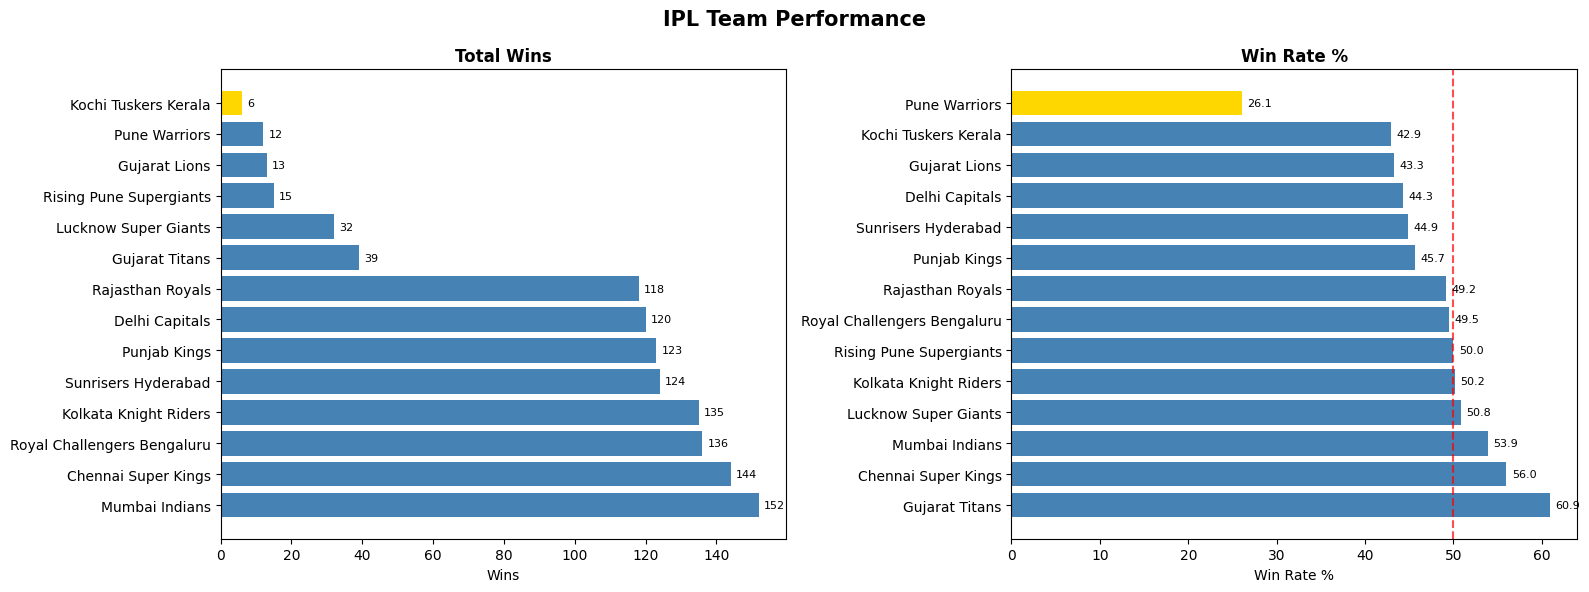

✅ Saved team_win_analysis.png


In [41]:
# ── CELL 5 ─ Team Win Visualisation ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('IPL Team Performance', fontsize=15, fontweight='bold')

def _hbar(ax, labels, vals, title, xlabel, cmap_col='steelblue'):
    clrs = ['gold' if i == 0 else cmap_col for i in range(len(labels))]
    ax.barh(labels, vals, color=clrs)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel(xlabel)
    ax.invert_yaxis()
    for i, v in enumerate(vals):
        ax.text(v + max(vals) * 0.01, i, str(v), va='center', fontsize=8)

ts = team_stats.sort_values('wins')
_hbar(axes[0], ts['team'], ts['wins'], 'Total Wins', 'Wins')
ts2 = team_stats.sort_values('win_rate')
_hbar(axes[1], ts2['team'], ts2['win_rate'], 'Win Rate %', 'Win Rate %')
axes[1].axvline(x=50, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('team_win_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved team_win_analysis.png")

Toss winner won: 50.8%

Win rate by decision:
toss_decision
bat      45.2
field    53.7
Name: toss_won_match, dtype: float64

Per team:
                             toss_wins  toss_appearances  win_rate
toss_winner                                                       
Gujarat Titans                      20                30      66.7
Gujarat Lions                       10                15      66.7
Rising Pune Supergiants              8                13      61.5
Chennai Super Kings                 78               129      60.5
Lucknow Super Giants                15                26      57.7
Kolkata Knight Riders               71               131      54.2
Mumbai Indians                      83               154      53.9
Royal Challengers Bengaluru         68               130      52.3
Kochi Tuskers Kerala                 4                 8      50.0
Rajasthan Royals                    64               131      48.9
Delhi Capitals                      66               142    

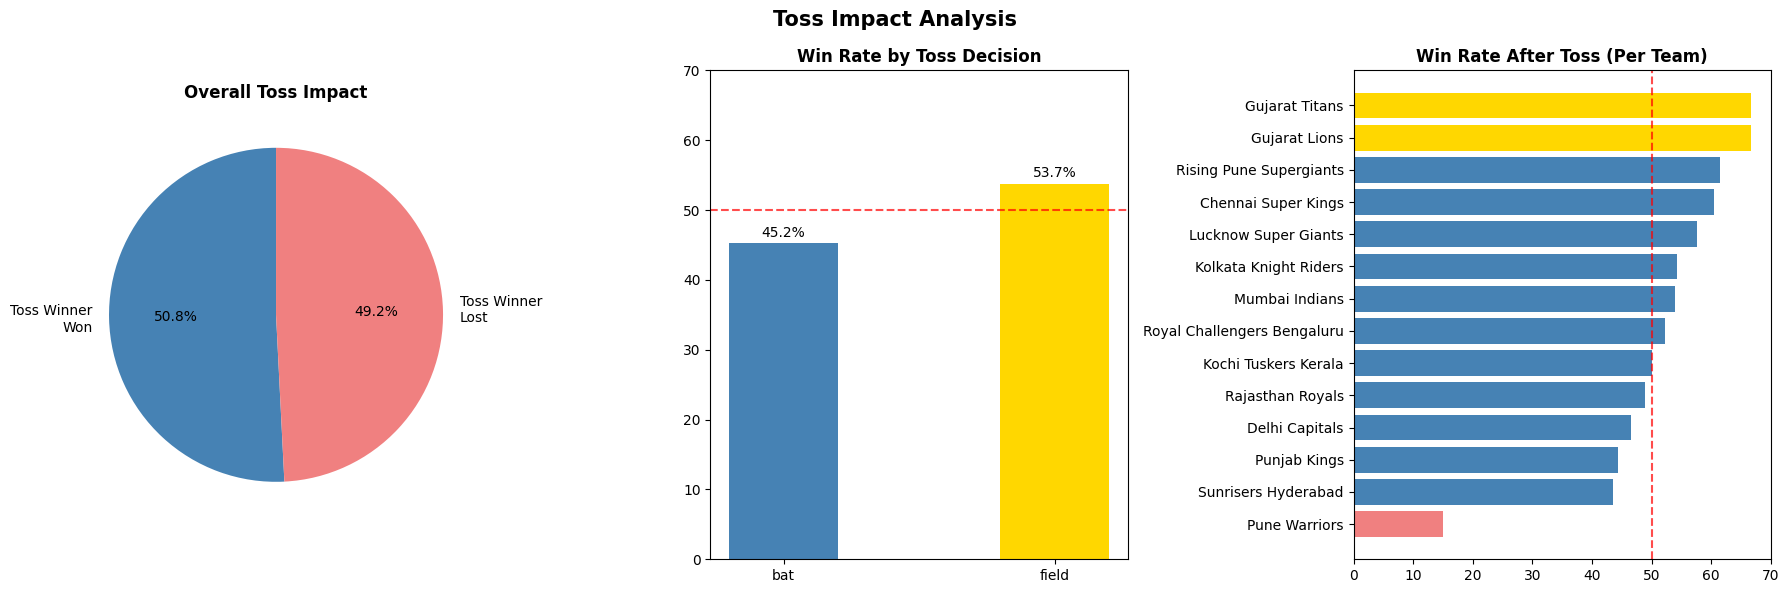

✅ Saved toss_analysis.png


In [42]:
# ── CELL 6 ─ Toss Analysis ────────────────────────────────────────────────────
matches['toss_won_match'] = matches['toss_winner'] == matches['match_won_by']
toss_win_pct = matches['toss_won_match'].mean() * 100

toss_dec_win = matches.groupby('toss_decision')['toss_won_match'].mean() * 100
team_toss    = matches.groupby('toss_winner')['toss_won_match'].agg(
    ['sum', 'count', 'mean']
).rename(columns={'sum':'toss_wins','count':'toss_appearances','mean':'win_rate'})
team_toss['win_rate'] = (team_toss['win_rate'] * 100).round(1)

print(f"Toss winner won: {toss_win_pct:.1f}%")
print(f"\nWin rate by decision:\n{toss_dec_win.round(1)}")
print(f"\nPer team:\n{team_toss.sort_values('win_rate', ascending=False).to_string()}")

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Toss Impact Analysis', fontsize=15, fontweight='bold')

axes[0].pie([toss_win_pct, 100-toss_win_pct],
            labels=['Toss Winner\nWon', 'Toss Winner\nLost'],
            colors=['steelblue', 'lightcoral'], autopct='%1.1f%%', startangle=90)
axes[0].set_title('Overall Toss Impact', fontweight='bold')

decs = toss_dec_win.index.tolist(); rates = toss_dec_win.values.tolist()
bars = axes[1].bar(decs, rates, color=['steelblue', 'gold'], width=0.4)
axes[1].set_title('Win Rate by Toss Decision', fontweight='bold')
axes[1].set_ylim(0, 70); axes[1].axhline(50, color='red', linestyle='--', alpha=0.7)
for b, r in zip(bars, rates):
    axes[1].text(b.get_x() + b.get_width()/2, b.get_height()+1, f'{r:.1f}%', ha='center')

tt = team_toss.sort_values('win_rate', ascending=True)
clrs = ['gold' if x==tt['win_rate'].max() else
        'lightcoral' if x==tt['win_rate'].min() else 'steelblue'
        for x in tt['win_rate']]
axes[2].barh(tt.index, tt['win_rate'], color=clrs)
axes[2].set_title('Win Rate After Toss (Per Team)', fontweight='bold')
axes[2].axvline(50, color='red', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('toss_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved toss_analysis.png")

In [43]:
# ── CELL 7 ─ Venue Stats ──────────────────────────────────────────────────────
VENUE_MAP = {
    'Wankhede Stadium, Mumbai'                                      : 'Wankhede Stadium',
    'M Chinnaswamy Stadium, Bengaluru'                              : 'M Chinnaswamy Stadium',
    'M.Chinnaswamy Stadium'                                         : 'M Chinnaswamy Stadium',
    'Eden Gardens, Kolkata'                                         : 'Eden Gardens',
    'Arun Jaitley Stadium, Delhi'                                   : 'Arun Jaitley Stadium',
    'Brabourne Stadium, Mumbai'                                     : 'Brabourne Stadium',
    'MA Chidambaram Stadium, Chepauk, Chennai'                      : 'MA Chidambaram Stadium, Chepauk',
    'MA Chidambaram Stadium, Chepauk'                               : 'MA Chidambaram Stadium, Chepauk',
    'Punjab Cricket Association IS Bindra Stadium, Mohali'          : 'PCA Stadium, Mohali',
    'Punjab Cricket Association IS Bindra Stadium'                  : 'PCA Stadium, Mohali',
    'Punjab Cricket Association Stadium, Mohali'                    : 'PCA Stadium, Mohali',
    'Rajiv Gandhi International Stadium, Uppal, Hyderabad'          : 'Rajiv Gandhi Intl Stadium',
    'Rajiv Gandhi International Stadium, Uppal'                     : 'Rajiv Gandhi Intl Stadium',
    'Rajiv Gandhi International Stadium'                            : 'Rajiv Gandhi Intl Stadium',
    'Maharashtra Cricket Association Stadium, Pune'                 : 'MCA Stadium, Pune',
    'Maharashtra Cricket Association Stadium'                       : 'MCA Stadium, Pune',
    'Subrata Roy Sahara Stadium'                                    : 'MCA Stadium, Pune',
    'Dr DY Patil Sports Academy, Mumbai'                            : 'Dr DY Patil Sports Academy',
    'Sardar Patel Stadium, Motera'                                  : 'Narendra Modi Stadium, Ahmedabad',
    'Bharat Ratna Shri Atal Bihari Vajpayee Ekana Cricket Stadium, Lucknow': 'Ekana Cricket Stadium, Lucknow',
    'Maharaja Yadavindra Singh International Cricket Stadium, Mullanpur'   : 'MYS Intl Stadium, Mullanpur',
    'Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium'          : 'ACA-VDCA Stadium',
    'Sawai Mansingh Stadium, Jaipur'                                : 'Sawai Mansingh Stadium',
}
ipl['venue']     = ipl['venue'].replace(VENUE_MAP)
matches['venue'] = matches['venue'].replace(VENUE_MAP)

# Compute venue stats
fi = ipl[ipl['innings'] == 1].groupby(['match_id', 'venue'])['runs_total'].sum().reset_index()
fi.columns = ['match_id', 'venue', 'first_innings_score']

venue_stats = fi.groupby('venue').agg(
    matches   = ('match_id', 'count'),
    avg_score = ('first_innings_score', 'mean')
).reset_index()

si       = ipl[ipl['innings'] == 2][['match_id', 'batting_team']].drop_duplicates()
chase_r  = matches[['match_id', 'venue', 'match_won_by']].merge(si, on='match_id')
chase_r['chase_won'] = chase_r['batting_team'] == chase_r['match_won_by']
chase_pct = chase_r.groupby('venue')['chase_won'].mean() * 100

venue_stats = venue_stats.merge(chase_pct.reset_index(), on='venue')
venue_stats.columns = ['venue', 'matches', 'avg_score', 'chase_win_pct']
venue_stats['avg_score']     = venue_stats['avg_score'].round(1)
venue_stats['chase_win_pct'] = venue_stats['chase_win_pct'].round(1)
venue_stats = venue_stats[venue_stats['matches'] >= 15].sort_values('avg_score', ascending=False)

print("=== VENUE STATS ===")
print(venue_stats.to_string(index=False))

=== VENUE STATS ===
                              venue  matches  avg_score  chase_win_pct
               Arun Jaitley Stadium       39      188.1           43.6
   Narendra Modi Stadium, Ahmedabad       46      181.0           47.8
                  Brabourne Stadium       27      178.5           48.1
              M Chinnaswamy Stadium      102      173.7           53.5
     Ekana Cricket Stadium, Lucknow       24      173.5           60.9
                   Wankhede Stadium      128      171.6           54.7
                       Eden Gardens      103      167.9           56.9
    MA Chidambaram Stadium, Chepauk       85      166.7           42.4
                PCA Stadium, Mohali       56      165.6           57.1
             Sawai Mansingh Stadium       64      165.5           64.1
          Rajiv Gandhi Intl Stadium       85      165.4           56.0
Dubai International Cricket Stadium       46      163.8           47.8
                  MCA Stadium, Pune       51      162.4  

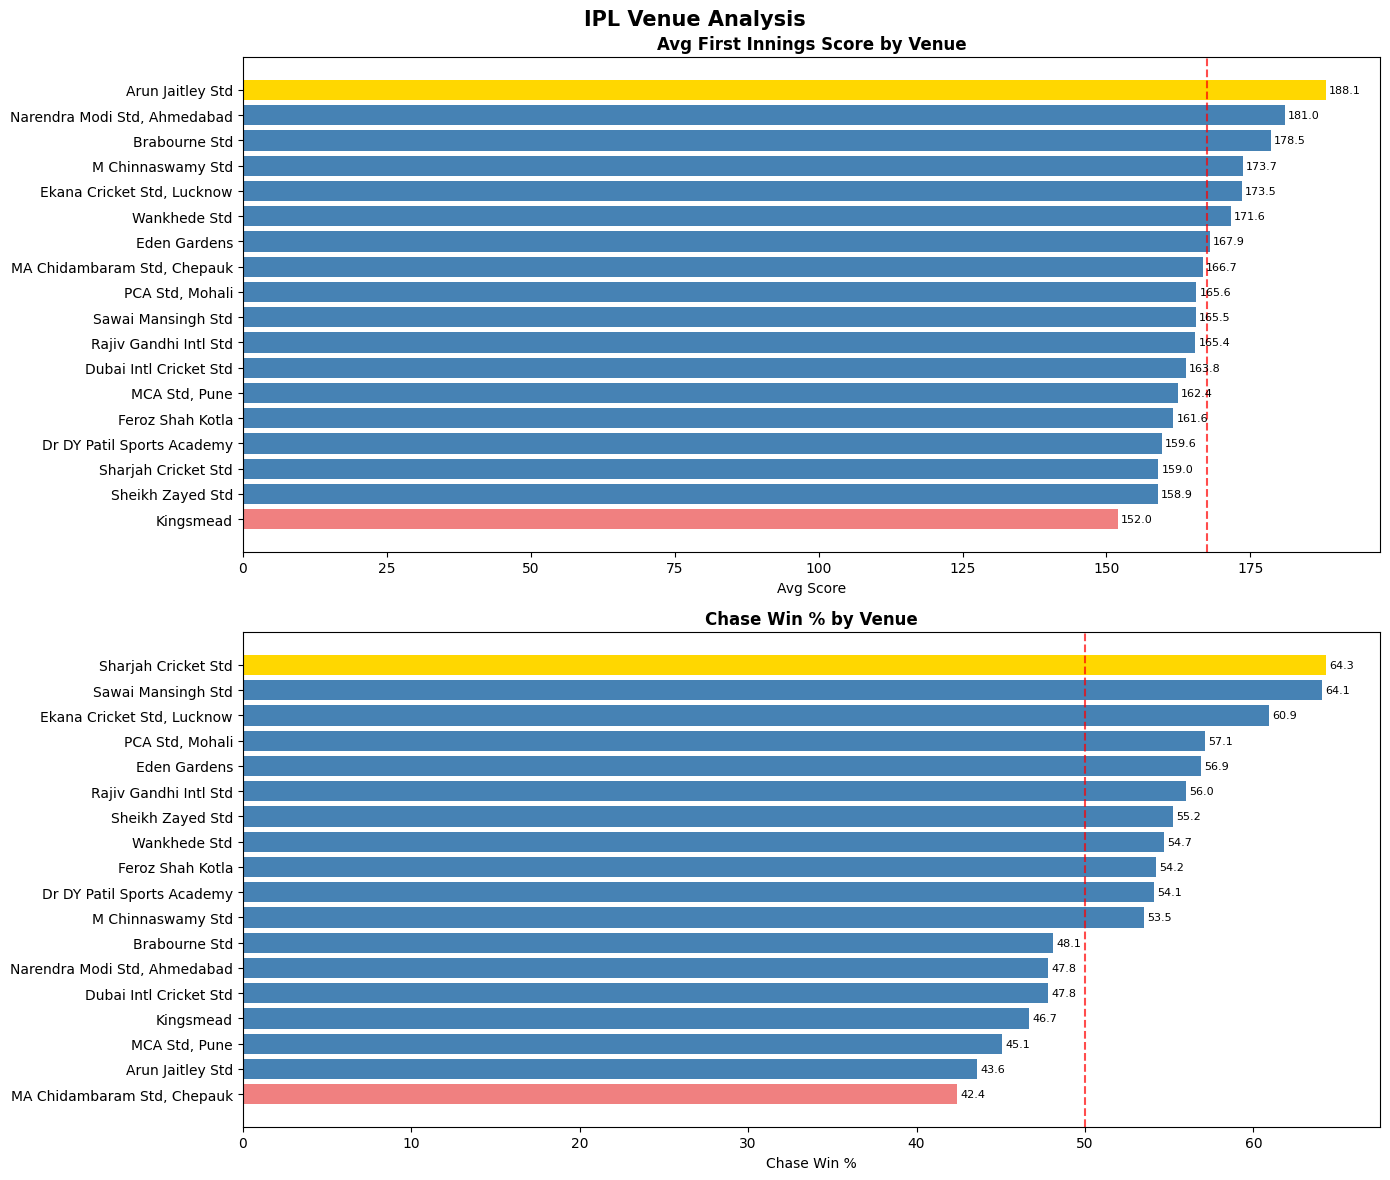

✅ Saved venue_analysis.png


In [44]:
# ── CELL 8 ─ Venue Visualisation ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 12))
fig.suptitle('IPL Venue Analysis', fontsize=15, fontweight='bold')

vs_score = venue_stats.sort_values('avg_score', ascending=True)
vs_chase = venue_stats.sort_values('chase_win_pct', ascending=True)
short    = lambda df: df['venue'].str.replace('Stadium','Std').str.replace('International','Intl')

def _venue_bar(ax, labels, vals, title, xlabel, ref=None):
    clrs = ['gold' if v==max(vals) else 'lightcoral' if v==min(vals) else 'steelblue' for v in vals]
    ax.barh(labels, vals, color=clrs)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel(xlabel)
    if ref: ax.axvline(x=ref, color='red', linestyle='--', alpha=0.7)
    for i, v in enumerate(vals):
        ax.text(v + max(vals)*0.003, i, str(v), va='center', fontsize=8)

_venue_bar(axes[0], short(vs_score), vs_score['avg_score'],
           'Avg First Innings Score by Venue', 'Avg Score',
           ref=venue_stats['avg_score'].mean())
_venue_bar(axes[1], short(vs_chase), vs_chase['chase_win_pct'],
           'Chase Win % by Venue', 'Chase Win %', ref=50)
plt.tight_layout()
plt.savefig('venue_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved venue_analysis.png")

In [45]:
# ── CELL 9 ─ Batter Stats ─────────────────────────────────────────────────────
batter_stats = ipl.groupby('batter').agg(
    innings      = ('match_id', 'nunique'),
    total_runs   = ('runs_batter', 'sum'),
    balls_faced  = ('valid_ball', 'sum'),
    sixes        = ('runs_batter', lambda x: (x==6).sum()),
    fours        = ('runs_batter', lambda x: (x==4).sum()),
    boundaries   = ('runs_batter', lambda x: ((x==4)|(x==6)).sum()),
    dot_balls    = ('runs_batter', lambda x: (x==0).sum()),
    dismissals   = ('player_out', 'count'),
).reset_index()

batter_stats['batting_avg']  = (batter_stats['total_runs'] / batter_stats['dismissals'].replace(0,1)).round(2)
batter_stats['strike_rate']  = (batter_stats['total_runs'] / batter_stats['balls_faced'] * 100).round(2)
batter_stats['boundary_pct'] = (batter_stats['boundaries'] / batter_stats['balls_faced'] * 100).round(2)
batter_stats['dot_pct']      = (batter_stats['dot_balls'] / batter_stats['balls_faced'] * 100).round(2)
batter_stats['six_rate']     = (batter_stats['sixes'] / batter_stats['balls_faced'] * 100).round(2)

batter_stats = batter_stats[batter_stats['innings'] >= 20].sort_values('total_runs', ascending=False)

print(f"Qualified batters (≥20 innings): {len(batter_stats)}")
print("\n=== TOP 15 RUN SCORERS ===")
print(batter_stats[['batter','innings','total_runs','batting_avg',
                     'strike_rate','boundary_pct','dot_pct']].head(15).to_string(index=False))

Qualified batters (≥20 innings): 230

=== TOP 15 RUN SCORERS ===
        batter  innings  total_runs  batting_avg  strike_rate  boundary_pct  dot_pct
       V Kohli      264        8899        37.87       133.84         16.53    35.79
     RG Sharma      270        7185        28.74       133.08         17.86    40.49
      S Dhawan      221        6769        34.89       127.62         17.36    40.27
     DA Warner      184        6567        40.04       140.32         19.21    40.02
      SK Raina      200        5536        32.95       137.54         17.64    36.67
      MS Dhoni      241        5439        34.42       138.22         16.24    37.64
      KL Rahul      139        5346        44.55       137.01         17.40    36.24
     AM Rahane      188        5184        30.32       125.73         15.89    38.90
AB de Villiers      170        5181        41.45       152.38         19.62    32.79
      CH Gayle      141        4997        39.04       150.02         23.03    49.11


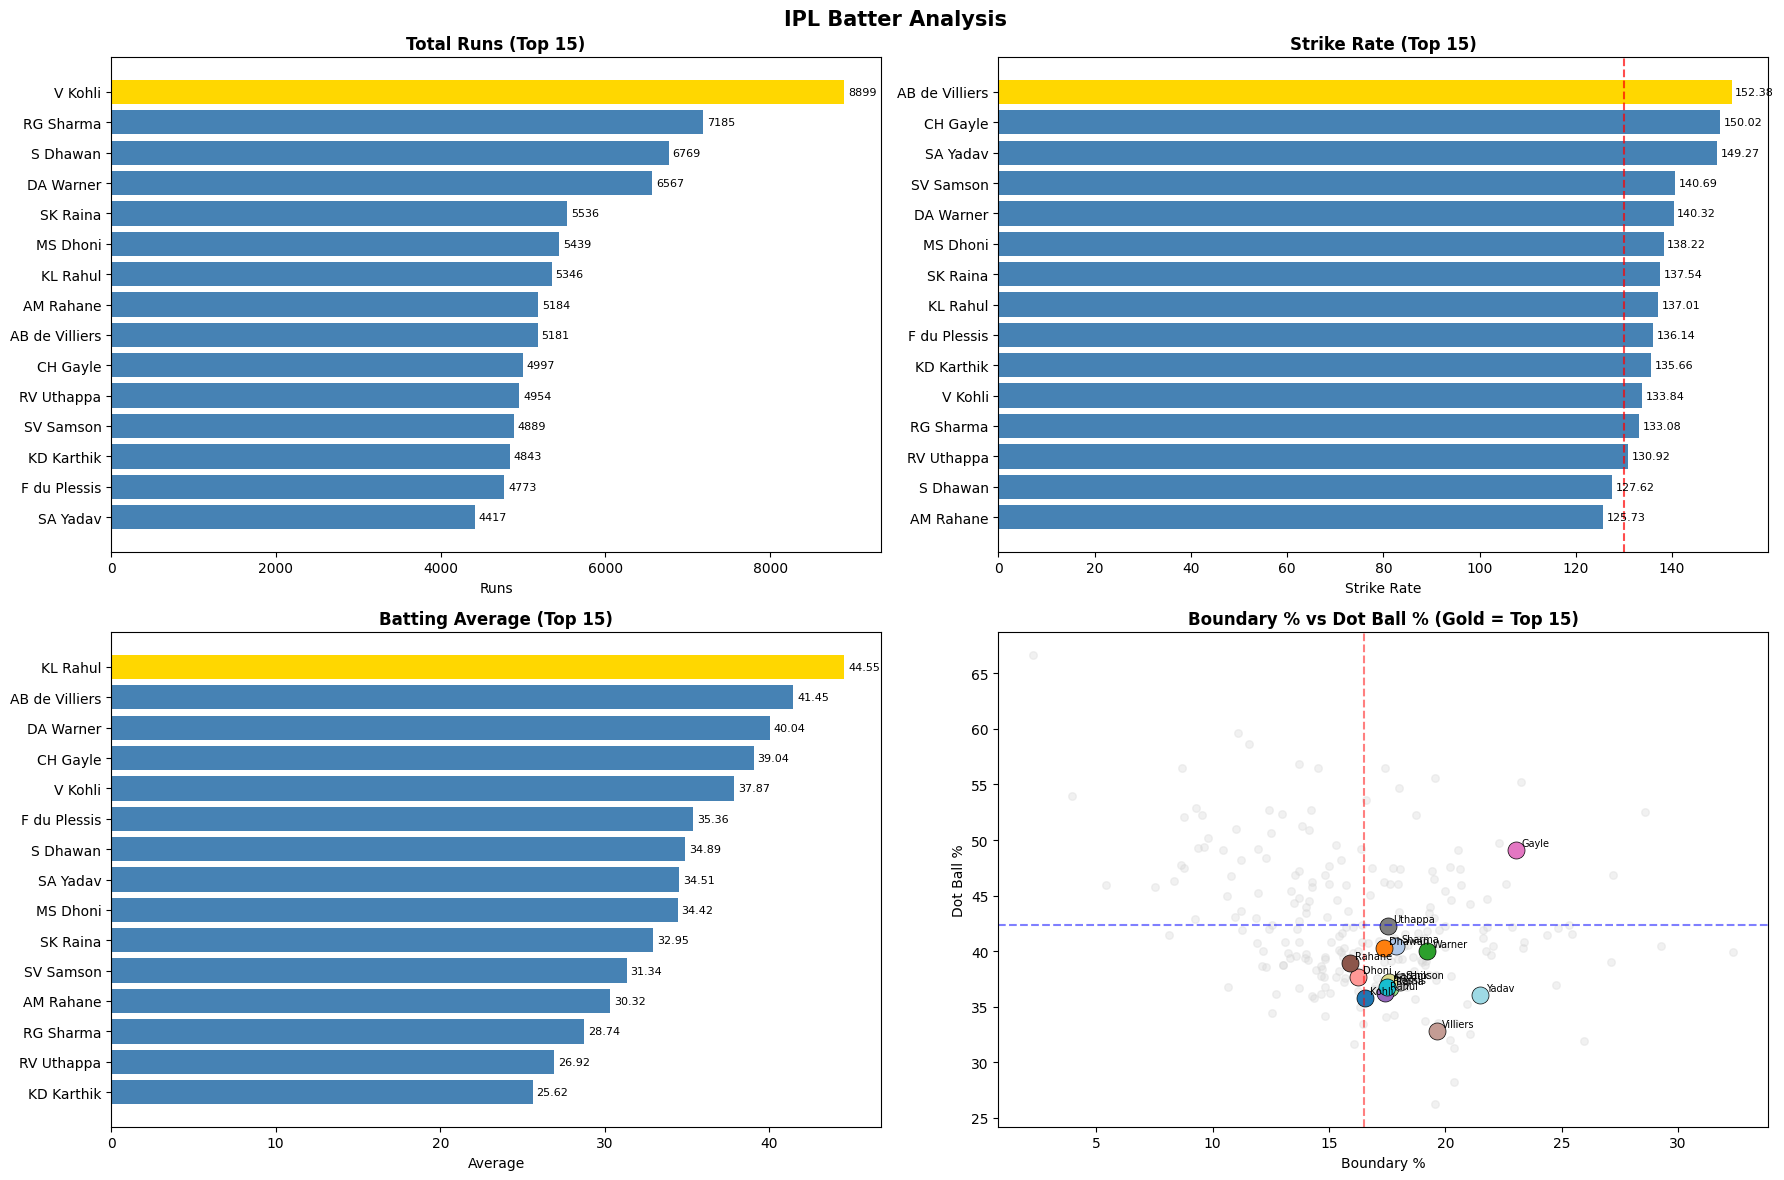

✅ Saved batter_analysis.png


In [46]:

# ── CELL 10 ─ Batter Visualisation ───────────────────────────────────────────
top15 = batter_stats.head(15)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('IPL Batter Analysis', fontsize=15, fontweight='bold')

def _hbar2(ax, labels, vals, title, xlabel, gold_max=True):
    ref = max(vals) if gold_max else min(vals)
    clrs = ['gold' if v==ref else 'steelblue' for v in vals]
    ax.barh(labels, vals, color=clrs)
    ax.set_title(title, fontweight='bold'); ax.set_xlabel(xlabel)
    for i, v in enumerate(vals):
        ax.text(v + max(vals)*0.005, i, str(v), va='center', fontsize=8)

t = top15.sort_values('total_runs', ascending=True)
_hbar2(axes[0,0], t['batter'], t['total_runs'], 'Total Runs (Top 15)', 'Runs')

t2 = top15.sort_values('strike_rate', ascending=True)
_hbar2(axes[0,1], t2['batter'], t2['strike_rate'], 'Strike Rate (Top 15)', 'Strike Rate')
axes[0,1].axvline(130, color='red', linestyle='--', alpha=0.7)

t3 = top15.sort_values('batting_avg', ascending=True)
_hbar2(axes[1,0], t3['batter'], t3['batting_avg'], 'Batting Average (Top 15)', 'Average')

colors_scatter = cm.tab20(np.linspace(0, 1, len(top15)))
others = batter_stats.iloc[15:]
axes[1,1].scatter(others['boundary_pct'], others['dot_pct'], alpha=0.3, color='lightgrey', s=30)
for i, (_, row) in enumerate(top15.iterrows()):
    axes[1,1].scatter(row['boundary_pct'], row['dot_pct'],
                      color=colors_scatter[i], s=150, edgecolors='black', lw=0.5)
    axes[1,1].annotate(row['batter'].split(' ')[-1],
                       (row['boundary_pct'], row['dot_pct']),
                       fontsize=7, xytext=(4,3), textcoords='offset points')
axes[1,1].axvline(batter_stats['boundary_pct'].mean(), color='red', linestyle='--', alpha=0.5)
axes[1,1].axhline(batter_stats['dot_pct'].mean(), color='blue', linestyle='--', alpha=0.5)
axes[1,1].set_title('Boundary % vs Dot Ball % (Gold = Top 15)', fontweight='bold')
axes[1,1].set_xlabel('Boundary %'); axes[1,1].set_ylabel('Dot Ball %')

plt.tight_layout()
plt.savefig('batter_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved batter_analysis.png")

In [47]:
# ── CELL 11 ─ Bowler Stats ────────────────────────────────────────────────────
bowler_stats = ipl.groupby('bowler').agg(
    innings       = ('match_id', 'nunique'),
    balls_bowled  = ('valid_ball', 'sum'),
    runs_conceded = ('runs_bowler', 'sum'),
    wickets       = ('bowler_wicket', 'sum'),
    dot_balls     = ('runs_bowler', lambda x: (x==0).sum()),
    boundaries    = ('runs_bowler', lambda x: ((x==4)|(x==6)).sum()),
).reset_index()

bowler_stats['overs_bowled'] = (bowler_stats['balls_bowled'] / 6).round(1)
bowler_stats['economy']      = (bowler_stats['runs_conceded'] / bowler_stats['overs_bowled']).round(2)
bowler_stats['bowling_avg']  = (bowler_stats['runs_conceded'] / bowler_stats['wickets'].replace(0,1)).round(2)
bowler_stats['strike_rate']  = (bowler_stats['balls_bowled'] / bowler_stats['wickets'].replace(0,1)).round(2)
bowler_stats['dot_pct']      = (bowler_stats['dot_balls'] / bowler_stats['balls_bowled'] * 100).round(2)
bowler_stats['wkt_rate']     = (bowler_stats['wickets'] / bowler_stats['balls_bowled'] * 6).round(3)

bowler_stats = bowler_stats[bowler_stats['innings'] >= 20].sort_values('wickets', ascending=False)

print(f"Qualified bowlers (≥20 innings): {len(bowler_stats)}")
print("\n=== TOP 15 WICKET TAKERS ===")
print(bowler_stats[['bowler','innings','wickets','economy',
                     'bowling_avg','strike_rate','dot_pct']].head(15).to_string(index=False))

Qualified bowlers (≥20 innings): 192

=== TOP 15 WICKET TAKERS ===
         bowler  innings  wickets  economy  bowling_avg  strike_rate  dot_pct
      YS Chahal      176      224     8.00        23.03        17.27    34.58
        B Kumar      195      205     7.72        27.25        21.18    43.64
      SP Narine      191      195     6.80        25.83        22.77    39.56
      PP Chawla      191      192     7.96        26.60        20.05    35.27
       R Ashwin      217      187     7.20        30.22        25.19    35.31
      JJ Bumrah      150      186     7.30        22.70        18.67    42.21
       DJ Bravo      158      183     8.38        23.83        17.05    33.78
       A Mishra      162      174     7.38        23.82        19.37    36.19
      RA Jadeja      228      173     7.68        30.32        23.69    32.99
     SL Malinga      122      170     7.14        19.80        16.63    43.05
    Rashid Khan      140      163     7.08        23.87        20.23    37.

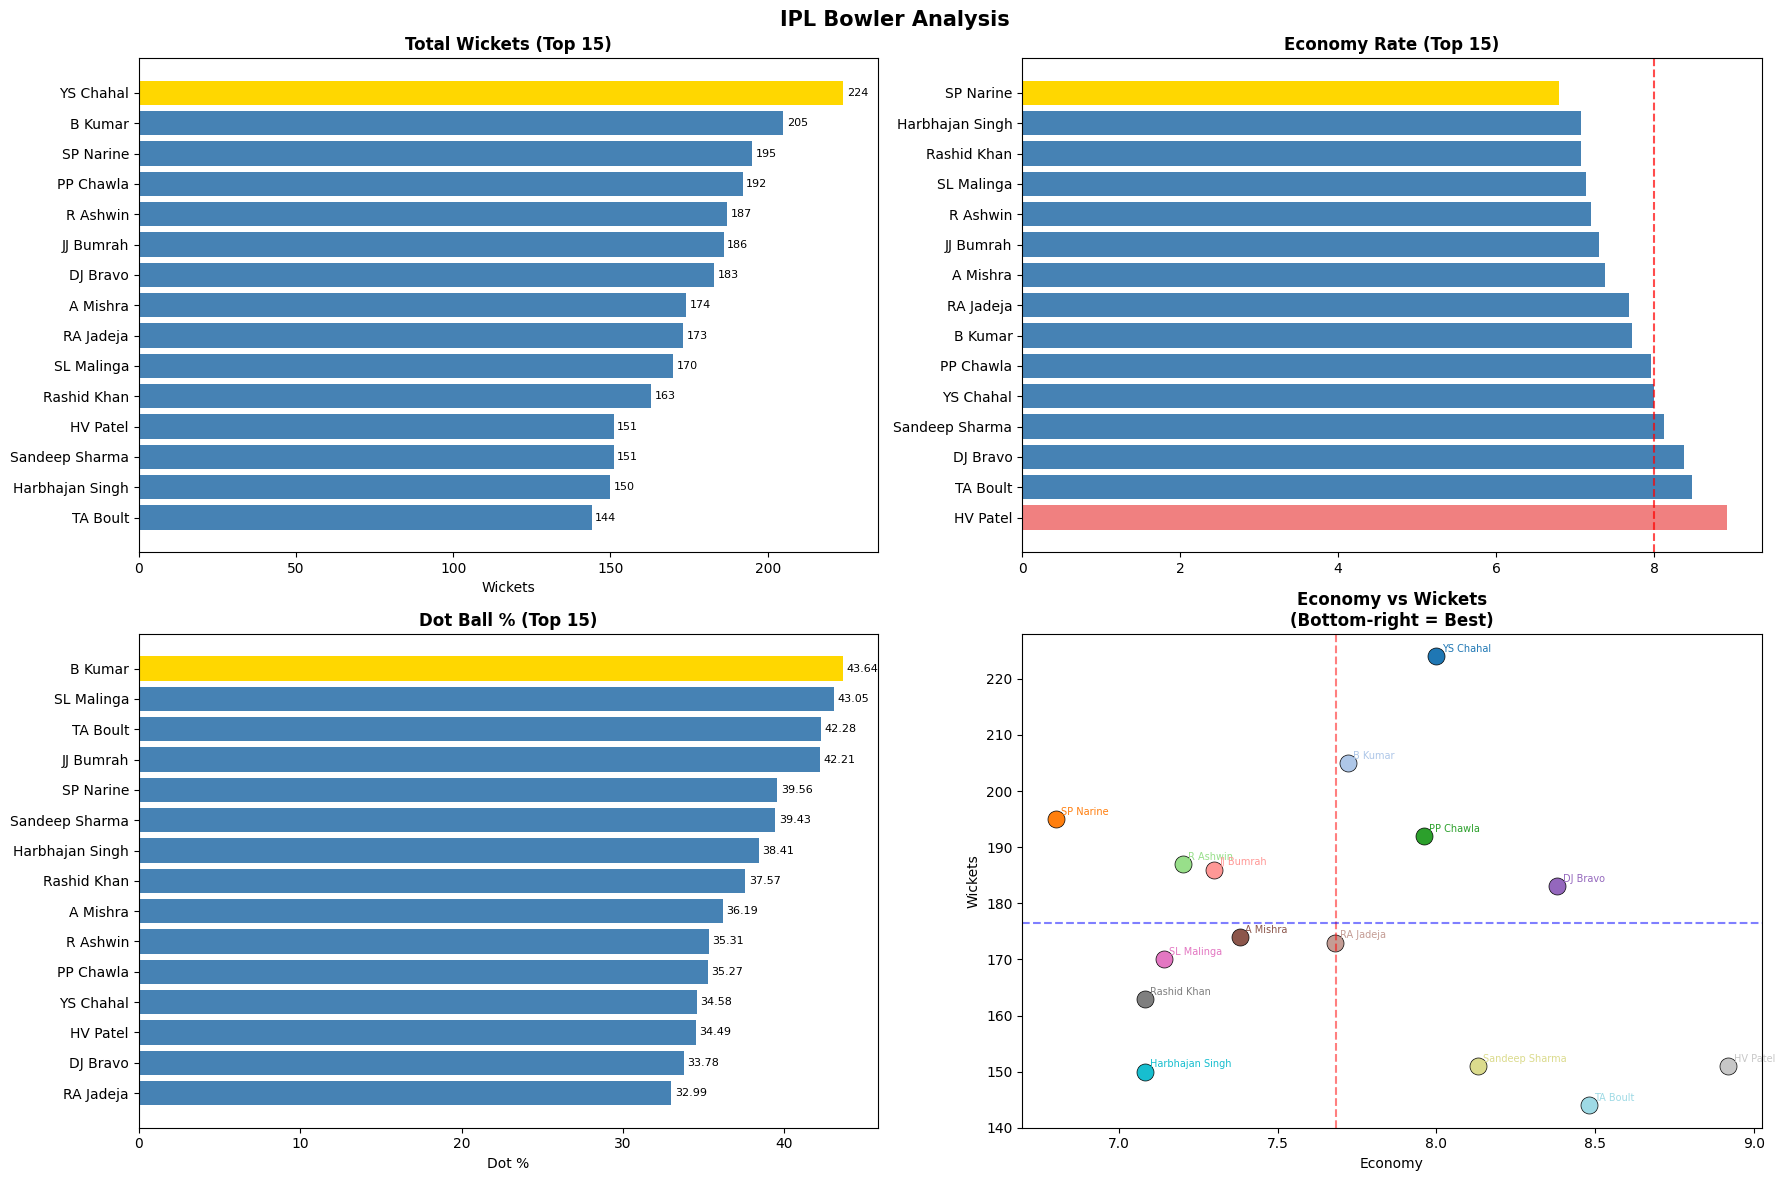

✅ Saved bowler_analysis.png


In [48]:
# ── CELL 12 ─ Bowler Visualisation ───────────────────────────────────────────
top15b = bowler_stats.head(15)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('IPL Bowler Analysis', fontsize=15, fontweight='bold')

t  = top15b.sort_values('wickets', ascending=True)
_hbar2(axes[0,0], t['bowler'], t['wickets'], 'Total Wickets (Top 15)', 'Wickets')

t2 = top15b.sort_values('economy', ascending=False)
clrs = ['gold' if v==t2['economy'].min() else 'lightcoral' if v==t2['economy'].max() else 'steelblue' for v in t2['economy']]
axes[0,1].barh(t2['bowler'], t2['economy'], color=clrs)
axes[0,1].set_title('Economy Rate (Top 15)', fontweight='bold')
axes[0,1].axvline(8.0, color='red', linestyle='--', alpha=0.7)

t3 = top15b.sort_values('dot_pct', ascending=True)
_hbar2(axes[1,0], t3['bowler'], t3['dot_pct'], 'Dot Ball % (Top 15)', 'Dot %')

colors_b = cm.tab20(np.linspace(0, 1, len(top15b)))
for i, (_, row) in enumerate(top15b.iterrows()):
    axes[1,1].scatter(row['economy'], row['wickets'],
                      color=colors_b[i], s=150, edgecolors='black', lw=0.5, label=row['bowler'])
    axes[1,1].annotate(row['bowler'], (row['economy'], row['wickets']),
                       fontsize=7, xytext=(4,3), textcoords='offset points', color=colors_b[i])
axes[1,1].axvline(top15b['economy'].mean(), color='red', linestyle='--', alpha=0.5)
axes[1,1].axhline(top15b['wickets'].mean(), color='blue', linestyle='--', alpha=0.5)
axes[1,1].set_title('Economy vs Wickets\n(Bottom-right = Best)', fontweight='bold')
axes[1,1].set_xlabel('Economy'); axes[1,1].set_ylabel('Wickets')

plt.tight_layout()
plt.savefig('bowler_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved bowler_analysis.png")

In [49]:
# ── CELL 13 ─ H2H Matchup Table ──────────────────────────────────────────────
h2h = ipl.groupby(['batter', 'bowler']).agg(
    balls      = ('valid_ball', 'sum'),
    runs       = ('runs_batter', 'sum'),
    dismissals = ('player_out', 'count'),
    dot_balls  = ('runs_batter', lambda x: (x==0).sum()),
    boundaries = ('runs_batter', lambda x: ((x==4)|(x==6)).sum()),
    sixes      = ('runs_batter', lambda x: (x==6).sum()),
    fours      = ('runs_batter', lambda x: (x==4).sum()),
).reset_index()

h2h['strike_rate']  = (h2h['runs'] / h2h['balls'] * 100).round(2)
h2h['dot_pct']      = (h2h['dot_balls'] / h2h['balls'] * 100).round(2)
h2h['boundary_pct'] = (h2h['boundaries'] / h2h['balls'] * 100).round(2)
h2h = h2h[h2h['balls'] >= 12]

print(f"Meaningful H2H matchups (≥12 balls): {len(h2h)}")

Meaningful H2H matchups (≥12 balls): 6890


In [50]:
# ── CELL 14 ─ H2H Lookup Functions ───────────────────────────────────────────
def batter_vs_bowler(batter_name, bowler_name):
    res = h2h[(h2h['batter']==batter_name) & (h2h['bowler']==bowler_name)]
    if res.empty:
        print(f"❌ No sufficient data for {batter_name} vs {bowler_name}"); return
    r = res.iloc[0]
    print(f"\n{'='*50}")
    print(f"🏏 {batter_name}  vs  🎯 {bowler_name}")
    print(f"{'='*50}")
    print(f"Balls Faced  : {r['balls']}")
    print(f"Runs Scored  : {r['runs']}")
    print(f"Dismissals   : {r['dismissals']}")
    print(f"Strike Rate  : {r['strike_rate']}")
    print(f"Dot Ball %   : {r['dot_pct']}%")
    print(f"Boundary %   : {r['boundary_pct']}%")
    print(f"Fours / Sixes: {r['fours']} / {r['sixes']}")
    if r['strike_rate'] > 130 and r['dismissals'] <= 1:
        print(f"\n🟢 {batter_name} DOMINATES")
    elif r['dismissals'] >= 3 or r['strike_rate'] < 100:
        print(f"\n🔴 {bowler_name} DOMINATES")
    else:
        print(f"\n🟡 EVEN matchup")

def who_dismisses_most(batter_name, top_n=5):
    res = h2h[h2h['batter']==batter_name].sort_values('dismissals', ascending=False).head(top_n)
    if res.empty:
        print(f"❌ No data for {batter_name}"); return
    print(f"\n🎯 Top {top_n} bowlers who dismiss {batter_name} most:")
    print(res[['bowler','balls','runs','dismissals','strike_rate','dot_pct']].to_string(index=False))

    fig, ax = plt.subplots(figsize=(10, 4))
    clrs = ['lightcoral' if v==res['dismissals'].max() else 'steelblue' for v in res['dismissals']]
    bars = ax.bar(res['bowler'], res['dismissals'], color=clrs)
    ax.set_title(f'Bowlers who dismiss {batter_name} most', fontweight='bold')
    for b, v in zip(bars, res['dismissals']):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.05, str(v), ha='center', fontweight='bold')
    plt.tight_layout(); plt.show()

def bowler_vs_all_batters(bowler_name, top_n=10):
    res = h2h[h2h['bowler']==bowler_name].sort_values('dismissals', ascending=False).head(top_n)
    if res.empty:
        print(f"❌ No data for {bowler_name}"); return
    print(f"\n🎯 {bowler_name} — Top {top_n} batters dismissed:")
    print(res[['batter','balls','runs','dismissals','strike_rate','dot_pct']].to_string(index=False))

def dangerous_matchup(team_batting, team_bowling, top_n=5):
    bat_players  = ipl[ipl['batting_team']==team_batting].groupby('batter')['runs_batter'].sum()\
                       .sort_values(ascending=False).head(8).index.tolist()
    bowl_players = ipl[ipl['bowling_team']==team_bowling].groupby('bowler')['bowler_wicket'].sum()\
                       .sort_values(ascending=False).head(8).index.tolist()

    matchups = h2h[(h2h['batter'].isin(bat_players)) & (h2h['bowler'].isin(bowl_players))].copy()
    if matchups.empty:
        print("No sufficient H2H data."); return

    matchups['dominance_score'] = (
        matchups['dismissals'] * 25 +
        (100 - matchups['strike_rate']) * 0.5 +
        matchups['dot_pct'] * 0.3
    ).round(2)

    top = matchups.sort_values('dominance_score', ascending=False).head(top_n)
    print(f"\nDangerous matchups: {team_batting} bat vs {team_bowling} bowl")
    print(top[['bowler','batter','balls','runs','dismissals',
               'strike_rate','dot_pct','dominance_score']].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Matchup: {team_batting} vs {team_bowling}', fontweight='bold')
    labels = [f"{r['bowler']} vs {r['batter']}" for _, r in top.iterrows()]
    axes[0].barh(labels, top['dominance_score'], color='#E74C3C')
    axes[0].set_title('Bowler Dominance Score'); axes[0].invert_yaxis()
    axes[1].barh(labels, top['strike_rate'], color='#2ECC71')
    axes[1].set_title('Batter SR in Matchup (lower = bowler wins)'); axes[1].invert_yaxis()
    axes[1].axvline(100, color='red', linestyle='--', alpha=0.7)
    plt.tight_layout(); plt.show()

print("✅ H2H functions ready")

✅ H2H functions ready


In [66]:
batter_vs_bowler('V Kohli', 'JJ Bumrah')


🏏 V Kohli  vs  🎯 JJ Bumrah
Balls Faced  : 110
Runs Scored  : 164
Dismissals   : 5
Strike Rate  : 149.09
Dot Ball %   : 36.36%
Boundary %   : 20.91%
Fours / Sixes: 17 / 6

🔴 JJ Bumrah DOMINATES



🏏 V Kohli  vs  🎯 JJ Bumrah
Balls Faced  : 110
Runs Scored  : 164
Dismissals   : 5
Strike Rate  : 149.09
Dot Ball %   : 36.36%
Boundary %   : 20.91%
Fours / Sixes: 17 / 6

🔴 JJ Bumrah DOMINATES

🎯 Top 5 bowlers who dismiss V Kohli most:
        bowler  balls  runs  dismissals  strike_rate  dot_pct
Sandeep Sharma     90   141           7       156.67    28.89
       A Nehra     54    60           6       111.11    55.56
     JJ Bumrah    110   164           5       149.09    36.36
Mohammed Shami     85   119           5       140.00    35.29
      UT Yadav     96   168           5       175.00    29.17


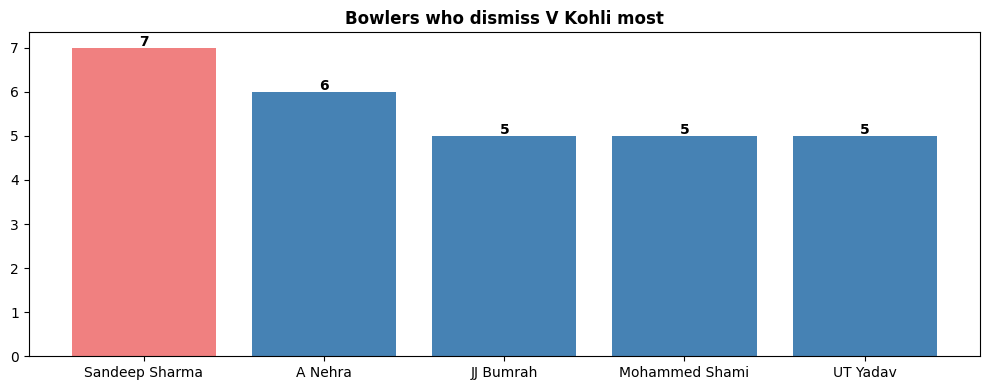


🎯 JJ Bumrah — Top 10 batters dismissed:
        batter  balls  runs  dismissals  strike_rate  dot_pct
       RR Pant     46    55           7       119.57    50.00
      MS Dhoni     64    62           5        96.88    48.44
       V Kohli    110   164           5       149.09    36.36
    GJ Maxwell     36    44           5       122.22    52.78
      AR Patel     52    53           5       101.92    40.38
    AD Russell     44    57           4       129.55    50.00
      DJ Bravo     27    35           4       129.63    55.56
    SO Hetmyer     19    11           4        57.89    47.37
AB de Villiers     88   131           3       148.86    40.91
     SR Watson     34    25           3        73.53    58.82

Dangerous matchups: Royal Challengers Bengaluru bat vs Mumbai Indians bowl
         bowler       batter  balls  runs  dismissals  strike_rate  dot_pct  dominance_score
Harbhajan Singh     CH Gayle    102   102           5       100.00    51.96           140.59
      JJ Bumrah

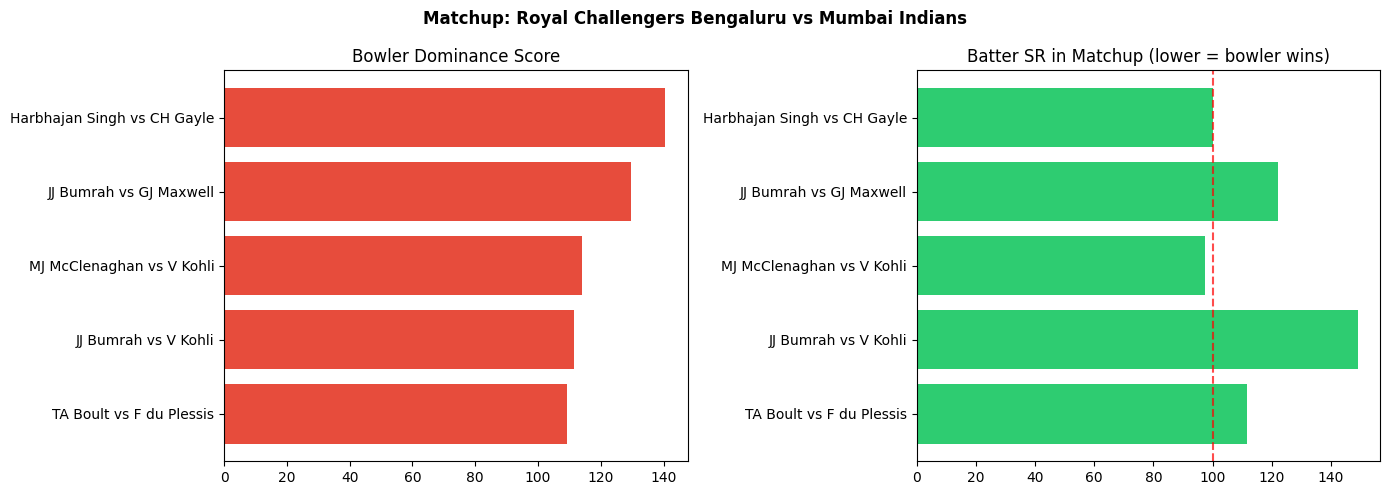

In [51]:
# ── CELL 15 ─ Sample H2H Queries ─────────────────────────────────────────────
who_dismisses_most('V Kohli')
bowler_vs_all_batters('JJ Bumrah')
dangerous_matchup('Royal Challengers Bengaluru', 'Mumbai Indians')

In [52]:
# ── CELL 16 ─ Venue Clustering ────────────────────────────────────────────────
venue_extra = ipl.groupby('venue').agg(
    boundary_pct = ('runs_batter', lambda x: ((x==4)|(x==6)).sum() / len(x) * 100),
    avg_wickets  = ('is_wicket', 'mean')
).reset_index()

venue_cluster_data = venue_stats.merge(venue_extra, on='venue').copy()
venue_cluster_data['boundary_pct'] = venue_cluster_data['boundary_pct'].round(2)
venue_cluster_data['avg_wickets']  = (venue_cluster_data['avg_wickets'] * 100).round(2)

X_v = venue_cluster_data[['avg_score','chase_win_pct','boundary_pct','avg_wickets']].values
scaler_v   = StandardScaler()
X_v_scaled = scaler_v.fit_transform(X_v)

km_venue = KMeans(n_clusters=3, init='k-means++', random_state=42, n_init=10)
venue_cluster_data['cluster'] = km_venue.fit_predict(X_v_scaled)

CLUSTER_NAMES_V = {0: 'Batting Paradise', 1: 'Chaser Friendly', 2: 'Bowler Friendly'}
venue_cluster_data['cluster_name'] = venue_cluster_data['cluster'].map(CLUSTER_NAMES_V)

venue_summary = venue_cluster_data.groupby('cluster').agg(
    venue_count  = ('venue', 'count'),
    avg_score    = ('avg_score', 'mean'),
    chase_win    = ('chase_win_pct', 'mean'),
    boundary_pct = ('boundary_pct', 'mean'),
    avg_wickets  = ('avg_wickets', 'mean')
).round(2)

print("=== VENUE CLUSTER SUMMARY ===")
print(venue_summary.to_string())
for i, name in CLUSTER_NAMES_V.items():
    vs = venue_cluster_data[venue_cluster_data['cluster']==i]['venue'].tolist()
    print(f"\n{name}:")
    for v in vs: print(f"  - {v}")

=== VENUE CLUSTER SUMMARY ===
         venue_count  avg_score  chase_win  boundary_pct  avg_wickets
cluster                                                              
0                  5     178.58      49.54         18.54         5.02
1                  8     164.68      58.59         16.41         4.85
2                  5     160.90      47.22         14.85         5.14

Batting Paradise:
  - Arun Jaitley Stadium
  - Narendra Modi Stadium, Ahmedabad
  - Brabourne Stadium
  - M Chinnaswamy Stadium
  - Wankhede Stadium

Chaser Friendly:
  - Ekana Cricket Stadium, Lucknow
  - Eden Gardens
  - PCA Stadium, Mohali
  - Sawai Mansingh Stadium
  - Rajiv Gandhi Intl Stadium
  - Feroz Shah Kotla
  - Sharjah Cricket Stadium
  - Sheikh Zayed Stadium

Bowler Friendly:
  - MA Chidambaram Stadium, Chepauk
  - Dubai International Cricket Stadium
  - MCA Stadium, Pune
  - Dr DY Patil Sports Academy
  - Kingsmead


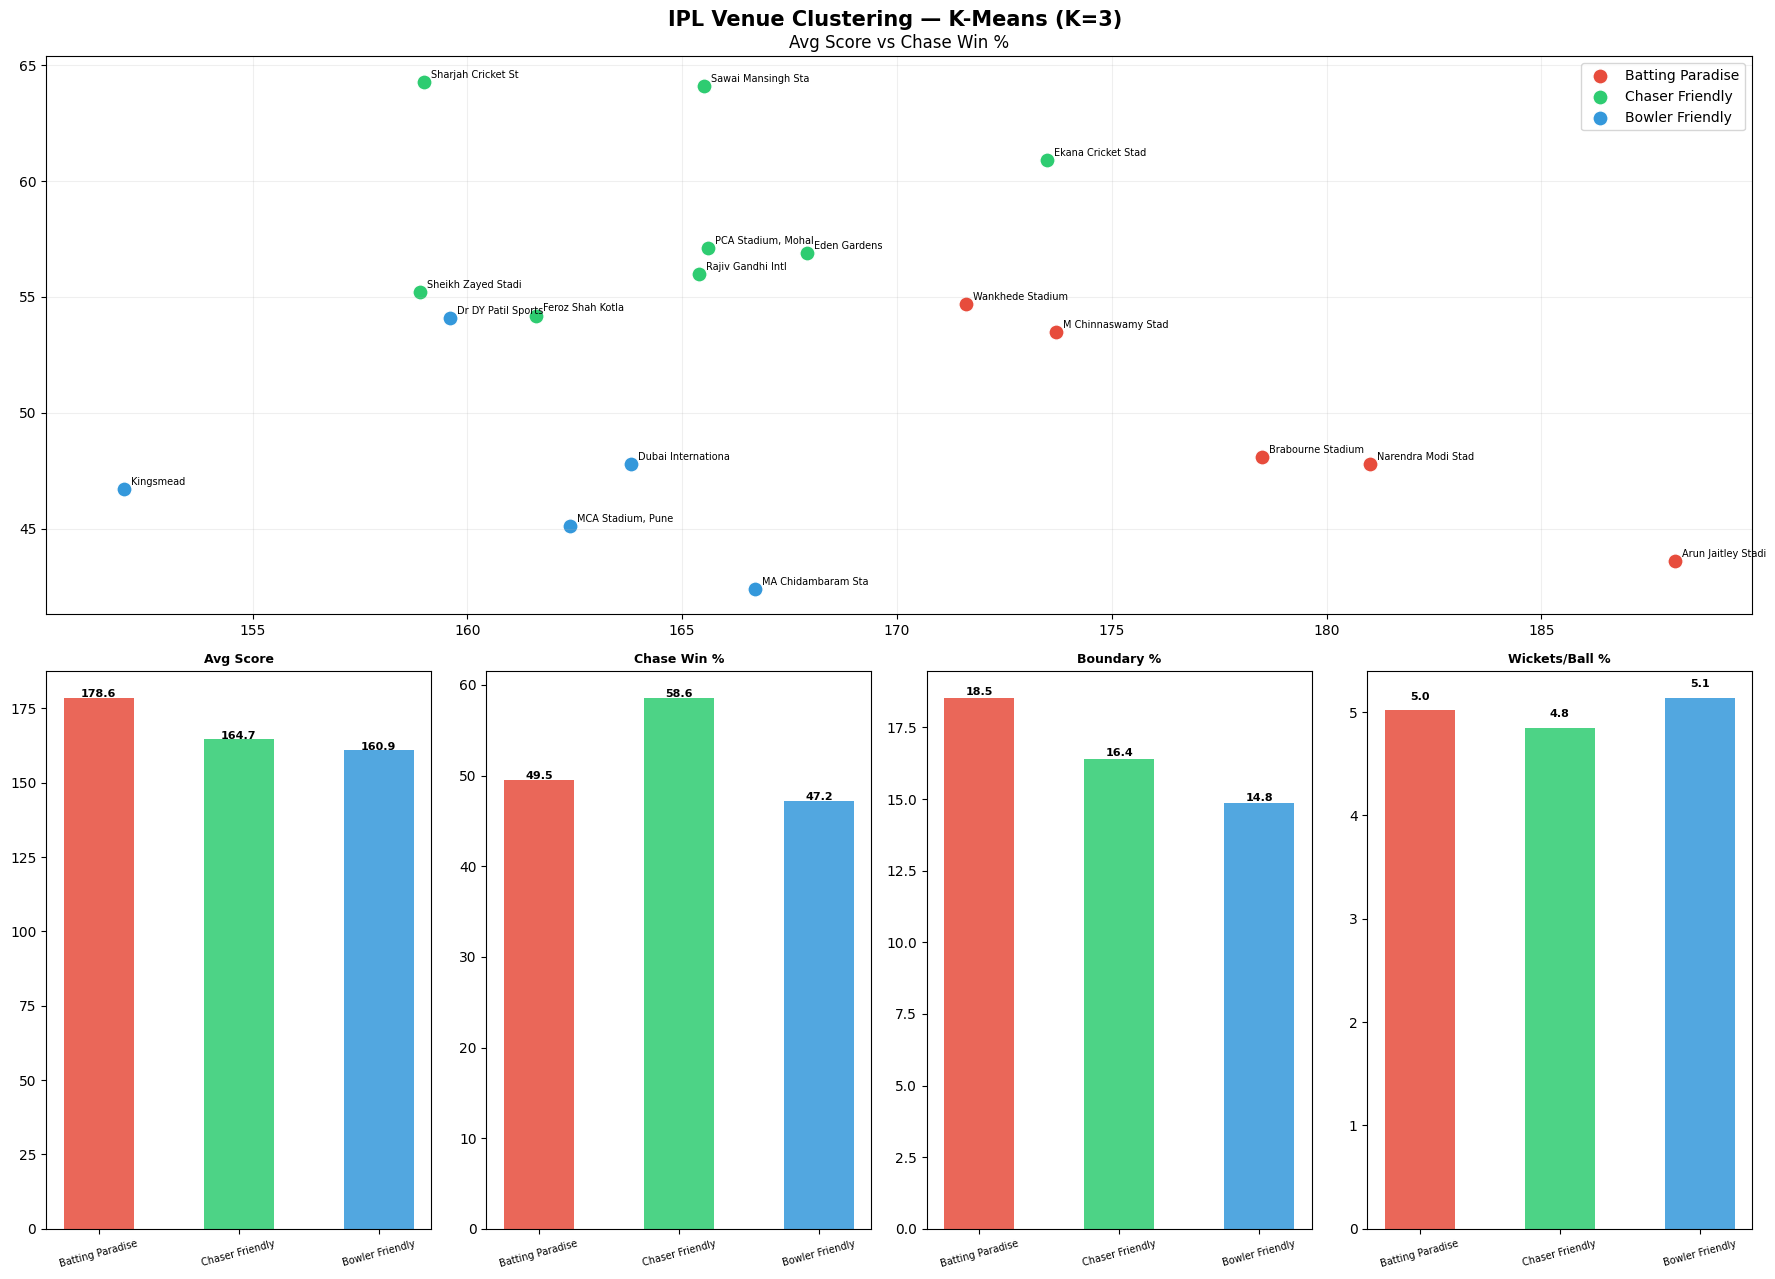

✅ Saved venue_clusters.png


In [53]:
# ── CELL 17 ─ Venue Cluster Visualisation ────────────────────────────────────
VCOL = {0:'#E74C3C', 1:'#2ECC71', 2:'#3498DB'}

fig = plt.figure(figsize=(18, 13))
fig.suptitle('IPL Venue Clustering — K-Means (K=3)', fontsize=15, fontweight='bold')

ax_sc = fig.add_subplot(2, 1, 1)
for cid, grp in venue_cluster_data.groupby('cluster'):
    ax_sc.scatter(grp['avg_score'], grp['chase_win_pct'],
                  c=VCOL[cid], label=CLUSTER_NAMES_V[cid], s=120, edgecolors='white')
    for _, row in grp.iterrows():
        ax_sc.annotate(row['venue'][:18], (row['avg_score'], row['chase_win_pct']),
                       fontsize=7, xytext=(5,3), textcoords='offset points')
ax_sc.set_title('Avg Score vs Chase Win %'); ax_sc.legend(); ax_sc.grid(alpha=0.2)

metrics_v = [('avg_score','Avg Score'),('chase_win','Chase Win %'),
             ('boundary_pct','Boundary %'),('avg_wickets','Wickets/Ball %')]
for i, (col, title) in enumerate(metrics_v):
    ax = fig.add_subplot(2, 4, 5+i)
    vals  = venue_summary[col].values
    names = [CLUSTER_NAMES_V[c] for c in range(3)]
    bars  = ax.bar(names, vals, color=list(VCOL.values()), alpha=0.85, width=0.5)
    ax.set_title(title, fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', labelsize=7, rotation=15)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.1, f'{v:.1f}',
                ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('venue_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved venue_clusters.png")

In [54]:
# ── CELL 18 ─ Batter Clustering ──────────────────────────────────────────────
cluster_data = batter_stats[['batter','strike_rate','batting_avg','boundary_pct','dot_pct']].dropna().copy()
X_b          = cluster_data[['strike_rate','batting_avg','boundary_pct','dot_pct']].values
scaler_b     = StandardScaler()
X_b_scaled   = scaler_b.fit_transform(X_b)

km_bat = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
cluster_data['cluster'] = km_bat.fit_predict(X_b_scaled)

CLUSTER_NAMES_B = {0:'Steady Accumulator', 1:'Elite Anchor', 2:'Tailender', 3:'Explosive Hitter'}
BCOL = {0:'#3498DB', 1:'#2ECC71', 2:'#E74C3C', 3:'#F39C12'}

print("=== BATTER CLUSTER SUMMARY ===")
print(cluster_data.groupby('cluster').agg(
    count   = ('batter','count'),
    avg_sr  = ('strike_rate','mean'),
    avg_avg = ('batting_avg','mean'),
    avg_bd  = ('boundary_pct','mean'),
    avg_dot = ('dot_pct','mean')
).round(2).to_string())

=== BATTER CLUSTER SUMMARY ===
         count  avg_sr  avg_avg  avg_bd  avg_dot
cluster                                         
0           88  123.06    21.05   15.10    42.76
1           69  139.96    31.83   17.79    36.97
2           34   96.54    10.65   10.38    50.81
3           39  153.82    27.81   22.77    43.37


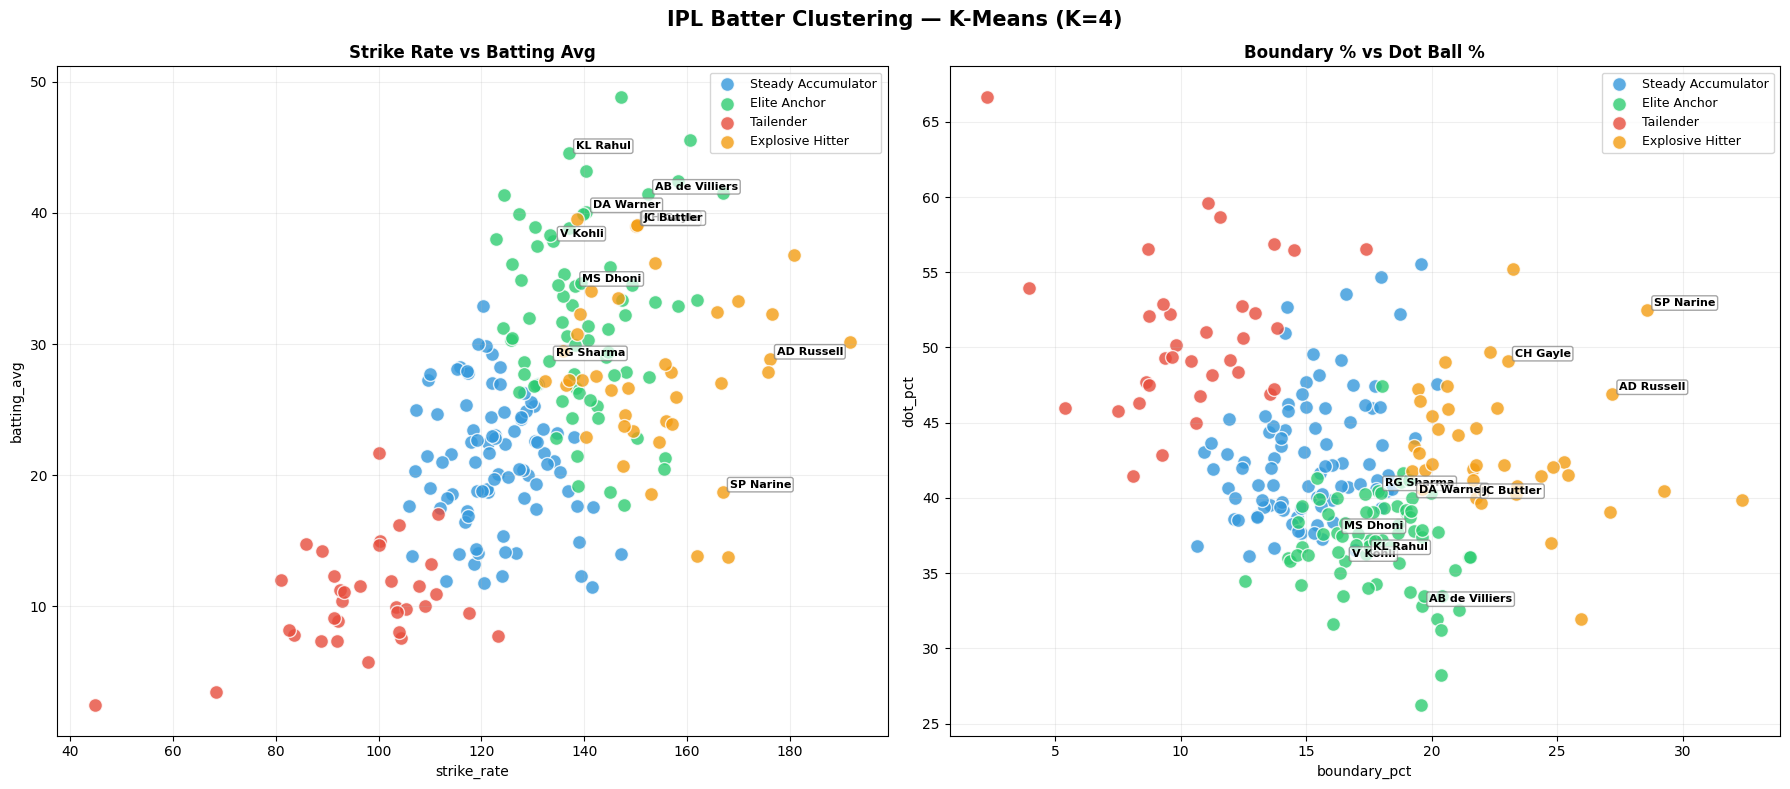

✅ Saved player_clusters.png


In [55]:
# ── CELL 19 ─ Batter Cluster Visualisation ───────────────────────────────────
FAMOUS = ['V Kohli','CH Gayle','MS Dhoni','AD Russell','DA Warner',
          'AB de Villiers','JC Buttler','KL Rahul','RG Sharma','SP Narine']

fig, axes = plt.subplots(1, 2, figsize=(18, 8))
fig.suptitle('IPL Batter Clustering — K-Means (K=4)', fontsize=15, fontweight='bold')

for ax_i, (xc, yc, title) in enumerate([
    ('strike_rate','batting_avg','Strike Rate vs Batting Avg'),
    ('boundary_pct','dot_pct','Boundary % vs Dot Ball %')
]):
    ax = axes[ax_i]
    for cid, grp in cluster_data.groupby('cluster'):
        ax.scatter(grp[xc], grp[yc], c=BCOL[cid],
                   label=CLUSTER_NAMES_B[cid], s=100, alpha=0.8, edgecolors='white')
    for _, row in cluster_data[cluster_data['batter'].isin(FAMOUS)].iterrows():
        ax.annotate(row['batter'], (row[xc], row[yc]),
                    fontsize=8, fontweight='bold', xytext=(5,3), textcoords='offset points',
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, ec='grey'))
    ax.set_title(title, fontweight='bold'); ax.set_xlabel(xc); ax.set_ylabel(yc)
    ax.legend(fontsize=9); ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('player_clusters.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved player_clusters.png")


Random Forest Accuracy : 60.3%
              precision    recall  f1-score   support

Bowling wins       0.65      0.66      0.66       137
Batting wins       0.54      0.52      0.53       102

    accuracy                           0.60       239
   macro avg       0.59      0.59      0.59       239
weighted avg       0.60      0.60      0.60       239



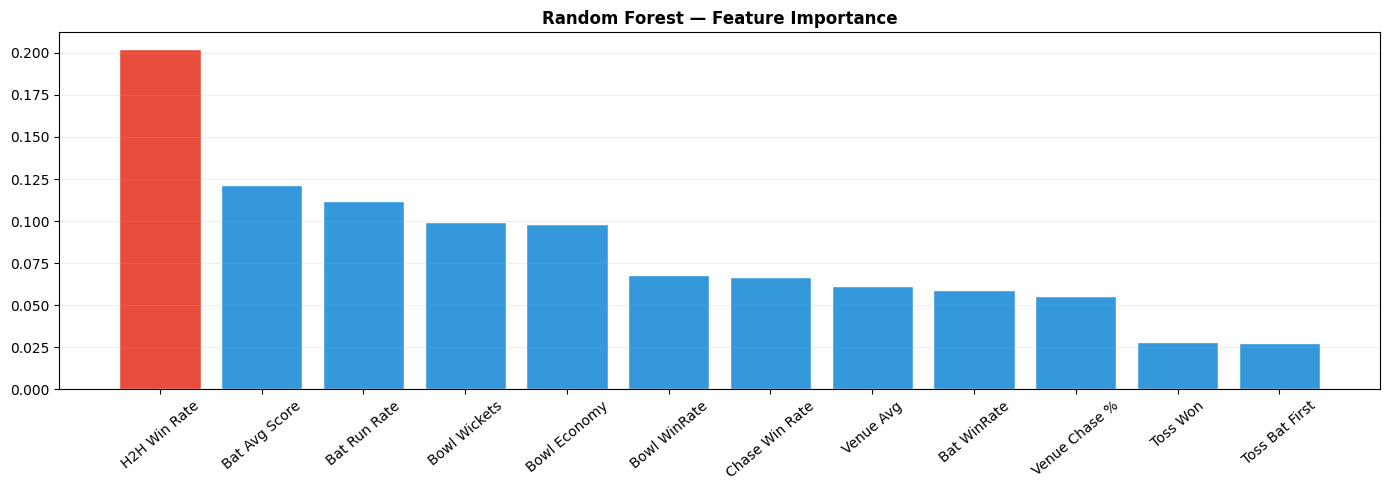

✅ Saved rf_feature_importance.png
✅ predict_match_winner() ready


In [56]:
# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 20 ─ ML: Match Winner Prediction ────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

# Build historical features
team_venue_batting = ipl[ipl['innings']==1].groupby(['batting_team','venue']).agg(
    matches     = ('match_id','nunique'),
    total_runs  = ('runs_total','sum'),
    total_balls = ('valid_ball','sum'),
).reset_index()
team_venue_batting['avg_score'] = (team_venue_batting['total_runs'] / team_venue_batting['matches']).round(1)
team_venue_batting['run_rate']  = (team_venue_batting['total_runs'] / (team_venue_batting['total_balls']/6)).round(2)

team_venue_bowling = ipl[ipl['innings']==2].groupby(['bowling_team','venue']).agg(
    matches       = ('match_id','nunique'),
    runs_conceded = ('runs_total','sum'),
    balls_bowled  = ('valid_ball','sum'),
    wickets       = ('is_wicket','sum'),
).reset_index()
team_venue_bowling['economy']          = (team_venue_bowling['runs_conceded'] / (team_venue_bowling['balls_bowled']/6)).round(2)
team_venue_bowling['wickets_per_match'] = (team_venue_bowling['wickets'] / team_venue_bowling['matches']).round(2)

_tmp = matches.copy()
_tmp['bat_won'] = (_tmp['match_won_by'] == _tmp['batting_team']).astype(int)
h2h_teams = _tmp.groupby(['batting_team','bowling_team'])['bat_won'].mean().reset_index()
h2h_teams.columns = ['team1','team2','h2h_win_rate']

si2 = ipl[ipl['innings']==2][['match_id','batting_team']].drop_duplicates().rename(columns={'batting_team':'chasing_team'})
team_chase_venue = matches.merge(si2, on='match_id')
team_chase_venue['won_chase'] = (team_chase_venue['chasing_team'] == team_chase_venue['match_won_by']).astype(int)
team_chase_rate  = team_chase_venue.groupby(['chasing_team','venue'])['won_chase'].mean().reset_index()
team_chase_rate.columns = ['team','venue','chase_win_rate']

win_rates = team_stats.set_index('team')['win_rate'].to_dict()

# Build training examples
sf = matches[['match_id','batting_team','bowling_team','toss_winner',
              'toss_decision','venue','match_won_by']].dropna(subset=['match_won_by']).copy()

sf = sf.merge(team_venue_batting[['batting_team','venue','avg_score','run_rate']],
              on=['batting_team','venue'], how='left')\
       .rename(columns={'avg_score':'bat_avg_score','run_rate':'bat_run_rate'})

sf = sf.merge(team_venue_bowling[['bowling_team','venue','economy','wickets_per_match']],
              on=['bowling_team','venue'], how='left')\
       .rename(columns={'economy':'bowl_economy','wickets_per_match':'bowl_wickets'})

sf = sf.merge(h2h_teams, left_on=['batting_team','bowling_team'],
              right_on=['team1','team2'], how='left').drop(columns=['team1','team2'])

sf = sf.merge(team_chase_rate, left_on=['batting_team','venue'],
              right_on=['team','venue'], how='left').drop(columns=['team'])

sf = sf.merge(venue_stats[['venue','avg_score','chase_win_pct']], on='venue', how='left')\
       .rename(columns={'avg_score':'venue_avg_score','chase_win_pct':'venue_chase_pct'})

sf['toss_bat_first'] = (sf['toss_decision']=='bat').astype(int)
sf['toss_won']       = (sf['toss_winner']==sf['batting_team']).astype(int)
sf['bat_team_winrate']  = sf['batting_team'].map(win_rates).fillna(50)
sf['bowl_team_winrate'] = sf['bowling_team'].map(win_rates).fillna(50)
sf['target'] = (sf['batting_team']==sf['match_won_by']).astype(int)

FEAT_COLS = ['bat_avg_score','bat_run_rate','bowl_economy','bowl_wickets',
             'h2h_win_rate','chase_win_rate','venue_avg_score','venue_chase_pct',
             'toss_bat_first','toss_won','bat_team_winrate','bowl_team_winrate']

for col in FEAT_COLS:
    sf[col] = sf[col].fillna(sf[col].median())

X, y = sf[FEAT_COLS].values, sf['target'].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=200, max_depth=15,
                             min_samples_split=5, random_state=42, n_jobs=-1)
rf.fit(X_tr, y_tr)
acc = accuracy_score(y_te, rf.predict(X_te))
print(f"\nRandom Forest Accuracy : {acc*100:.1f}%")
print(classification_report(y_te, rf.predict(X_te),
      target_names=['Bowling wins','Batting wins']))

# Feature importance chart
FEAT_LABELS = ['Bat Avg Score','Bat Run Rate','Bowl Economy','Bowl Wickets',
               'H2H Win Rate','Chase Win Rate','Venue Avg','Venue Chase %',
               'Toss Bat First','Toss Won','Bat WinRate','Bowl WinRate']
imp  = rf.feature_importances_
sidx = imp.argsort()[::-1]

fig, ax = plt.subplots(figsize=(14, 5))
clrs = ['#E74C3C' if v==max(imp) else '#3498DB' for v in imp[sidx]]
ax.bar([FEAT_LABELS[i] for i in sidx], imp[sidx], color=clrs, edgecolor='white')
ax.set_title('Random Forest — Feature Importance', fontweight='bold')
ax.tick_params(axis='x', rotation=40); ax.grid(alpha=0.2, axis='y')
plt.tight_layout()
plt.savefig('rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved rf_feature_importance.png")

# ── CELL 21 ─ Match Winner Prediction Function ────────────────────────────────
TEAM_ALIASES_FULL = {
    'csk':'Chennai Super Kings',   'mi':'Mumbai Indians',
    'rcb':'Royal Challengers Bengaluru', 'kkr':'Kolkata Knight Riders',
    'srh':'Sunrisers Hyderabad',   'dc':'Delhi Capitals',
    'rr':'Rajasthan Royals',       'pbks':'Punjab Kings',
    'gt':'Gujarat Titans',         'lsg':'Lucknow Super Giants',
    'mumbai':'Mumbai Indians',     'chennai':'Chennai Super Kings',
    'bangalore':'Royal Challengers Bengaluru',
    'bengaluru':'Royal Challengers Bengaluru',
    'kolkata':'Kolkata Knight Riders','hyderabad':'Sunrisers Hyderabad',
    'delhi':'Delhi Capitals',      'jaipur':'Rajasthan Royals',
    'gujarat':'Gujarat Titans',    'lucknow':'Lucknow Super Giants',
    'royal challengers bangalore':'Royal Challengers Bengaluru',
    'kings xi punjab':'Punjab Kings',
}

VENUE_ALIASES_FULL = {
    'wankhede':'Wankhede Stadium',
    'chinnaswamy':'M Chinnaswamy Stadium',
    'chepauk':'MA Chidambaram Stadium, Chepauk',
    'eden':'Eden Gardens',
    'kotla':'Arun Jaitley Stadium',
    'motera':'Narendra Modi Stadium, Ahmedabad',
    'narendra modi':'Narendra Modi Stadium, Ahmedabad',
    'ekana':'Ekana Cricket Stadium, Lucknow',
    'mohali':'PCA Stadium, Mohali',
    'sharjah':'Sharjah Cricket Stadium',
    'dubai':'Dubai International Cricket Stadium',
    'sawai mansingh':'Sawai Mansingh Stadium',
    'jaipur':'Sawai Mansingh Stadium',
    'pune':'MCA Stadium, Pune',
    'hyderabad':'Rajiv Gandhi Intl Stadium',
    'mumbai':'Wankhede Stadium',
    'chennai':'MA Chidambaram Stadium, Chepauk',
    'kolkata':'Eden Gardens',
    'delhi':'Arun Jaitley Stadium',
    'ahmedabad':'Narendra Modi Stadium, Ahmedabad',
    'bangalore':'M Chinnaswamy Stadium',
    'bengaluru':'M Chinnaswamy Stadium',
    'lucknow':'Ekana Cricket Stadium, Lucknow',
    # team abbr → home ground
    'rcb':'M Chinnaswamy Stadium',  'mi':'Wankhede Stadium',
    'csk':'MA Chidambaram Stadium, Chepauk', 'kkr':'Eden Gardens',
    'srh':'Rajiv Gandhi Intl Stadium', 'dc':'Arun Jaitley Stadium',
    'rr':'Sawai Mansingh Stadium',  'pbks':'PCA Stadium, Mohali',
    'gt':'Narendra Modi Stadium, Ahmedabad', 'lsg':'Ekana Cricket Stadium, Lucknow',
}

def _resolve(name, table):
    return table.get(name.strip().lower(), name) if name else name

def _lookup(df, filters, col, fallback):
    mask = df.copy()
    for k, v in filters.items(): mask = mask[mask[k]==v]
    return mask[col].values[0] if len(mask)>0 else fallback

def predict_match_winner(team1, team2, venue_in, toss_winner, toss_decision):
    t1   = _resolve(team1,       TEAM_ALIASES_FULL)
    t2   = _resolve(team2,       TEAM_ALIASES_FULL)
    tw   = _resolve(toss_winner, TEAM_ALIASES_FULL)
    ven  = _resolve(venue_in,    VENUE_ALIASES_FULL)
    tdec = 'bat' if toss_decision.strip().lower() in ('bat','batting','bat first') else 'field'

    known_t = list(win_rates.keys())
    known_v = venue_stats['venue'].tolist()
    if t1 not in known_t:  print(f"Unknown team: {t1}"); return
    if t2 not in known_t:  print(f"Unknown team: {t2}"); return
    if ven not in known_v: print(f"Unknown venue: {ven}"); return

    def features(bat, bowl, toss_w, toss_d):
        b_avg = _lookup(team_venue_batting, {'batting_team':bat,'venue':ven},
                        'avg_score', team_venue_batting[team_venue_batting['batting_team']==bat]['avg_score'].mean())
        b_rr  = _lookup(team_venue_batting, {'batting_team':bat,'venue':ven},
                        'run_rate',  team_venue_batting[team_venue_batting['batting_team']==bat]['run_rate'].mean())
        e     = _lookup(team_venue_bowling, {'bowling_team':bowl,'venue':ven},
                        'economy',         team_venue_bowling[team_venue_bowling['bowling_team']==bowl]['economy'].mean())
        wpm   = _lookup(team_venue_bowling, {'bowling_team':bowl,'venue':ven},
                        'wickets_per_match',team_venue_bowling[team_venue_bowling['bowling_team']==bowl]['wickets_per_match'].mean())
        h2h_w = _lookup(h2h_teams, {'team1':bat,'team2':bowl}, 'h2h_win_rate', 0.5)
        cwr   = _lookup(team_chase_rate, {'team':bat,'venue':ven}, 'chase_win_rate', 0.5)
        v     = venue_stats[venue_stats['venue']==ven]
        v_avg = v['avg_score'].values[0]     if not v.empty else 160
        v_ch  = v['chase_win_pct'].values[0] if not v.empty else 50
        t_won = 1 if toss_w==bat else 0
        t_bat = 1 if toss_d=='bat' else 0
        return np.array([[b_avg,b_rr,e,wpm,h2h_w,cwr,v_avg,v_ch,t_bat,t_won,
                           win_rates.get(bat,50),win_rates.get(bowl,50)]])

    p1 = rf.predict_proba(features(t1,t2,tw,tdec))[0][1]
    p2 = rf.predict_proba(features(t2,t1,tw,tdec))[0][1]
    tot = p1+p2
    p1n, p2n = p1/tot*100, p2/tot*100

    print(f"\n{'='*50}")
    print(f"  {t1}  vs  {t2}")
    print(f"  Venue : {ven}")
    print(f"  Toss  : {tw} chose to {tdec}")
    print(f"{'='*50}")
    print(f"  {t1:<38}: {p1n:.1f}%")
    print(f"  {t2:<38}: {p2n:.1f}%")
    verdict = f"{t1} FAVOURED" if p1n>55 else f"{t2} FAVOURED" if p2n>55 else "CLOSE MATCH"
    print(f"\n  Verdict : {verdict}")

    fig, ax = plt.subplots(figsize=(9,3))
    ax.barh([t2,t1],[p2n,p1n], color=['#3498DB','#E74C3C'], edgecolor='white', height=0.4)
    ax.axvline(50, color='grey', linestyle='--', alpha=0.6); ax.set_xlim(0,100)
    ax.set_xlabel('Win Probability (%)'); ax.set_facecolor('#F8F9FA')
    ax.set_title(f'{t1}  vs  {t2}\n{ven}', fontweight='bold')
    for i, v in enumerate([p2n,p1n]):
        ax.text(v+0.8, i, f'{v:.1f}%', va='center', fontweight='bold')
    plt.tight_layout(); plt.show()

print("✅ predict_match_winner() ready")



  Royal Challengers Bengaluru  vs  Chennai Super Kings
  Venue : Wankhede Stadium
  Toss  : Chennai Super Kings chose to field
  Royal Challengers Bengaluru           : 55.6%
  Chennai Super Kings                   : 44.4%

  Verdict : Royal Challengers Bengaluru FAVOURED


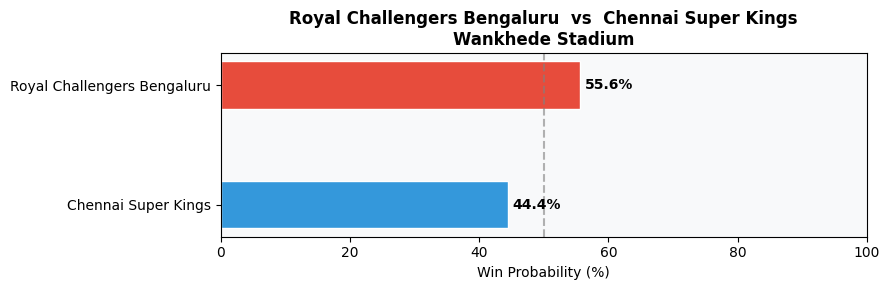

In [57]:
predict_match_winner('rcb', 'csk', 'mumbai', 'csk', 'bowl')


  Mumbai Indians  vs  Kolkata Knight Riders
  Venue : Wankhede Stadium
  Toss  : Mumbai Indians chose to field
  Mumbai Indians                        : 80.9%
  Kolkata Knight Riders                 : 19.1%

  Verdict : Mumbai Indians FAVOURED


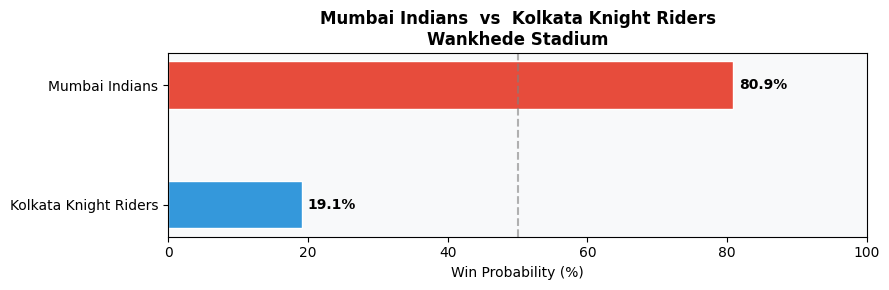

In [58]:
predict_match_winner('mi', 'kkr', 'wankhede', 'mi', 'field')

Score Predictor — MAE: 9.6 runs | R²: 0.858


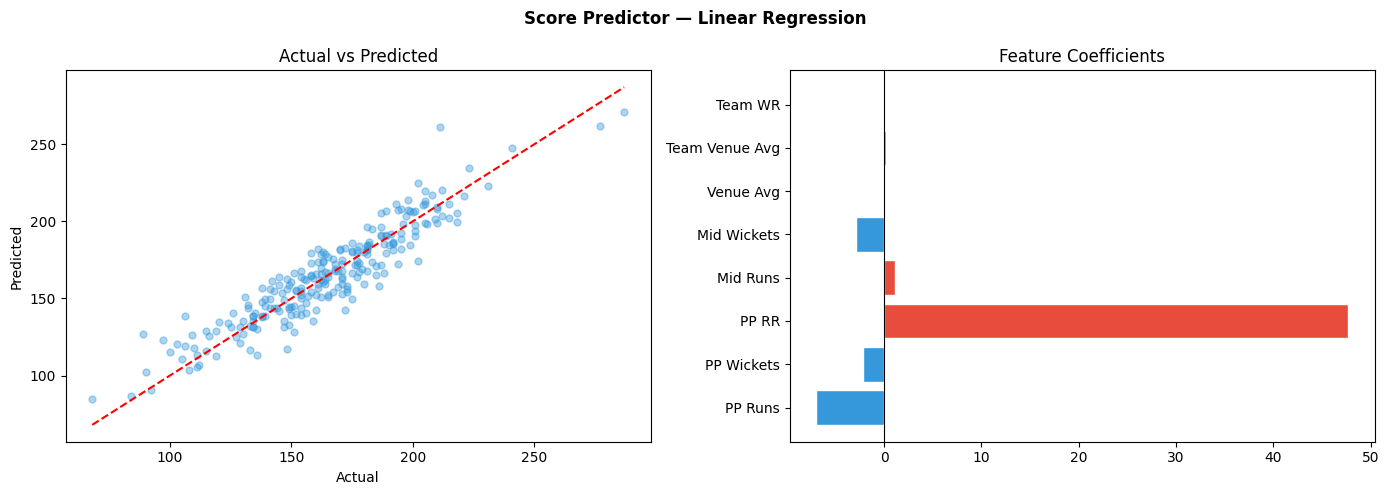

✅ Saved score_predictor.png
✅ predict_final_score() ready


In [59]:
# ── CELL 22 ─ Score Predictor ─────────────────────────────────────────────────
pp_data  = ipl[(ipl['innings']==1) & (ipl['over']<=5)].groupby('match_id').agg(
    pp_runs    = ('runs_total','sum'),
    pp_wickets = ('is_wicket','sum'),
    pp_balls   = ('valid_ball','sum'),
).reset_index()
pp_data['pp_run_rate'] = (pp_data['pp_runs']/(pp_data['pp_balls']/6)).round(2)

mid_data = ipl[(ipl['innings']==1) & (ipl['over']>=6) & (ipl['over']<=15)]\
    .groupby('match_id').agg(mid_runs=('runs_total','sum'), mid_wickets=('is_wicket','sum')).reset_index()

fi_score = ipl[ipl['innings']==1].groupby(['match_id','batting_team','venue'])['runs_total']\
    .sum().reset_index(); fi_score.columns = ['match_id','batting_team','venue','final_score']

sd = fi_score.merge(pp_data, on='match_id').merge(mid_data, on='match_id')
sd = sd.merge(venue_stats[['venue','avg_score']], on='venue', how='left').rename(columns={'avg_score':'venue_avg'})
sd = sd.merge(team_venue_batting[['batting_team','venue','avg_score']], on=['batting_team','venue'], how='left').rename(columns={'avg_score':'team_venue_avg'})
sd['team_winrate'] = sd['batting_team'].map(win_rates).fillna(50)
for c in ['venue_avg','team_venue_avg']: sd[c] = sd[c].fillna(sd[c].median())
sd = sd.dropna()

SCORE_FEATS = ['pp_runs','pp_wickets','pp_run_rate','mid_runs','mid_wickets',
               'venue_avg','team_venue_avg','team_winrate']
Xs, ys = sd[SCORE_FEATS].values, sd['final_score'].values
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(Xs_tr, ys_tr)
ys_pred = lr.predict(Xs_te)
print(f"Score Predictor — MAE: {mean_absolute_error(ys_te,ys_pred):.1f} runs | R²: {r2_score(ys_te,ys_pred):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Score Predictor — Linear Regression', fontweight='bold')
axes[0].scatter(ys_te, ys_pred, alpha=0.4, color='#3498DB', s=25)
axes[0].plot([ys_te.min(),ys_te.max()],[ys_te.min(),ys_te.max()], color='red', linestyle='--')
axes[0].set_title('Actual vs Predicted'); axes[0].set_xlabel('Actual'); axes[0].set_ylabel('Predicted')

SLABELS = ['PP Runs','PP Wickets','PP RR','Mid Runs','Mid Wickets','Venue Avg','Team Venue Avg','Team WR']
clrs2 = ['#E74C3C' if c>0 else '#3498DB' for c in lr.coef_]
axes[1].barh(SLABELS, lr.coef_, color=clrs2, edgecolor='white')
axes[1].set_title('Feature Coefficients'); axes[1].axvline(0, color='black', lw=0.8)
plt.tight_layout()
plt.savefig('score_predictor.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved score_predictor.png")

def predict_final_score(batting_team, venue_in, pp_runs, pp_wickets, mid_runs, mid_wickets):
    ven   = _resolve(venue_in, VENUE_ALIASES_FULL)
    pp_rr = pp_runs / (36/6)
    v_avg = venue_stats[venue_stats['venue']==ven]['avg_score']
    v_avg = v_avg.values[0] if not v_avg.empty else 160
    tv    = team_venue_batting[(team_venue_batting['batting_team']==batting_team)&
                               (team_venue_batting['venue']==ven)]['avg_score']
    tv_avg= tv.values[0] if not tv.empty else v_avg
    t_wr  = win_rates.get(batting_team, 50)
    pred  = lr.predict([[pp_runs,pp_wickets,pp_rr,mid_runs,mid_wickets,v_avg,tv_avg,t_wr]])[0]
    print(f"\nScore Prediction")
    print(f"{'='*40}")
    print(f"Team       : {batting_team}")
    print(f"Venue      : {ven}")
    print(f"Powerplay  : {pp_runs}/{pp_wickets} (RR: {pp_rr:.1f})")
    print(f"Middle     : {mid_runs}/{mid_wickets}")
    print(f"{'='*40}")
    print(f"Predicted Final Score : {pred:.0f}")

print("✅ predict_final_score() ready")

In [60]:
predict_final_score('Mumbai Indians', 'kkr', pp_runs=76, pp_wickets=4,mid_runs=28, mid_wickets=1)


Score Prediction
Team       : Mumbai Indians
Venue      : Eden Gardens
Powerplay  : 76/4 (RR: 12.7)
Middle     : 28/1
Predicted Final Score : 141


In [69]:
predict_final_score('csk', 'mi', pp_runs=50, pp_wickets=2,mid_runs=80, mid_wickets=3)


Score Prediction
Team       : csk
Venue      : Wankhede Stadium
Powerplay  : 50/2 (RR: 8.3)
Middle     : 80/3
Predicted Final Score : 170


In [61]:

# ══════════════════════════════════════════════════════════════════════════════
# ── CELL 23 ─ NLP Query System ────────────────────────────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

VENUES_LIST   = venue_cluster_data['venue'].tolist()
ALL_PLAYERS   = list(set(ipl['batter'].dropna().tolist() + ipl['bowler'].dropna().tolist()))
PLAYERS_LOWER = {p.lower(): p for p in ALL_PLAYERS}
TEAMS_LOWER   = {t.lower(): t for t in ipl['batting_team'].unique()}
ALL_YEARS     = sorted(ipl['year'].dropna().unique().astype(int).tolist())
PLAYER_BLACKLIST = ['T Kohli','V Kohli SR','S Kohli']

NLP_TEAM_ALIASES = {
    'csk':'Chennai Super Kings',    'mi':'Mumbai Indians',
    'rcb':'Royal Challengers Bengaluru','kkr':'Kolkata Knight Riders',
    'srh':'Sunrisers Hyderabad',    'dc':'Delhi Capitals',
    'rr':'Rajasthan Royals',        'pbks':'Punjab Kings',
    'gt':'Gujarat Titans',          'lsg':'Lucknow Super Giants',
    'kxip':'Punjab Kings',          'dd':'Delhi Capitals',
    'mumbai':'Mumbai Indians',      'chennai':'Chennai Super Kings',
    'bangalore':'Royal Challengers Bengaluru',
    'bengaluru':'Royal Challengers Bengaluru',
    'kolkata':'Kolkata Knight Riders','hyderabad':'Sunrisers Hyderabad',
    'delhi':'Delhi Capitals',       'jaipur':'Rajasthan Royals',
    'gujarat':'Gujarat Titans',     'lucknow':'Lucknow Super Giants',
    'royal challengers bangalore':'Royal Challengers Bengaluru',
    'kings xi punjab':'Punjab Kings',
}

NLP_VENUE_ALIASES = {
    'wankhede':'Wankhede Stadium',
    'chinnaswamy':'M Chinnaswamy Stadium',
    'chepauk':'MA Chidambaram Stadium, Chepauk',
    'eden':'Eden Gardens',
    'kotla':'Arun Jaitley Stadium', 'feroz shah':'Arun Jaitley Stadium',
    'arun jaitley':'Arun Jaitley Stadium',
    'mohali':'PCA Stadium, Mohali',
    'brabourne':'Brabourne Stadium',
    'narendra modi':'Narendra Modi Stadium, Ahmedabad',
    'motera':'Narendra Modi Stadium, Ahmedabad',
    'ekana':'Ekana Cricket Stadium, Lucknow',
    'sharjah':'Sharjah Cricket Stadium',
    'dubai':'Dubai International Cricket Stadium',
    'sawai mansingh':'Sawai Mansingh Stadium',
    'dy patil':'Dr DY Patil Sports Academy',
    'mullanpur':'MYS Intl Stadium, Mullanpur',
    'blr':'M Chinnaswamy Stadium',  'bom':'Wankhede Stadium',
    'mumbai':'Wankhede Stadium',    'chennai':'MA Chidambaram Stadium, Chepauk',
    'kolkata':'Eden Gardens',       'delhi':'Arun Jaitley Stadium',
    'ahmedabad':'Narendra Modi Stadium, Ahmedabad',
    'lucknow':'Ekana Cricket Stadium, Lucknow',
    'jaipur':'Sawai Mansingh Stadium', 'pune':'MCA Stadium, Pune',
    'hyderabad':'Rajiv Gandhi Intl Stadium',
    'bangalore':'M Chinnaswamy Stadium','bengaluru':'M Chinnaswamy Stadium',
    # team abbr → home ground
    'rcb':'M Chinnaswamy Stadium',  'mi':'Wankhede Stadium',
    'csk':'MA Chidambaram Stadium, Chepauk','kkr':'Eden Gardens',
    'srh':'Rajiv Gandhi Intl Stadium','dc':'Arun Jaitley Stadium',
    'rr':'Sawai Mansingh Stadium',  'pbks':'PCA Stadium, Mohali',
    'gt':'Narendra Modi Stadium, Ahmedabad','lsg':'Ekana Cricket Stadium, Lucknow',
}

PLAYER_ALIASES_NLP = {
    'kohli':'V Kohli',         'virat':'V Kohli',
    'rohit':'RG Sharma',       'dhoni':'MS Dhoni',  'msd':'MS Dhoni',
    'bumrah':'JJ Bumrah',      'gayle':'CH Gayle',
    'warner':'DA Warner',      'dhawan':'S Dhawan',
    'rahul':'KL Rahul',        'chahal':'YS Chahal',
    'jadeja':'RA Jadeja',      'pollard':'KA Pollard',
    'russell':'AD Russell',    'narine':'SP Narine',
    'buttler':'JC Buttler',    'maxwell':'GJ Maxwell',
    'rashid':'Rashid Khan',    'pant':'RR Pant',
    'hardik':'HH Pandya',      'malinga':'SL Malinga',
    'ashwin':'R Ashwin',       'shami':'Mohammed Shami',
    'boult':'TA Boult',        'sachin':'SR Tendulkar',
    'tendulkar':'SR Tendulkar','samson':'SV Samson',
    'gaikwad':'RD Gaikwad',
}

def _ex_venue(query):
    q = query.lower()
    for alias in sorted(NLP_VENUE_ALIASES.keys(), key=len, reverse=True):
        if len(alias)>2 and alias in q:
            return NLP_VENUE_ALIASES[alias]
    for v in VENUES_LIST:
        words = [w for w in v.lower().split() if len(w)>3]
        if words and words[0] in q: return v
    return None

def _ex_player(query):
    q = query.lower()
    for alias in sorted(PLAYER_ALIASES_NLP.keys(), key=len, reverse=True):
        if re.search(r'\b'+re.escape(alias)+r'\b', q):
            return PLAYER_ALIASES_NLP[alias]
    return None

def _ex_two_players(query):
    q    = query.lower()
    found, seen = [], []
    for alias in sorted(PLAYER_ALIASES_NLP.keys(), key=len, reverse=True):
        if re.search(r'\b'+re.escape(alias)+r'\b', q):
            full = PLAYER_ALIASES_NLP[alias]
            if full in PLAYER_BLACKLIST: continue
            last = full.split(' ')[-1]
            if last in seen or full in found: continue
            found.append(full); seen.append(last)
        if len(found)==2: return found
    if len(found)<2:
        for pl, po in PLAYERS_LOWER.items():
            if po in PLAYER_BLACKLIST: continue
            last = pl.split(' ')[-1]
            if len(last)>3 and last in q and po not in found and last not in seen:
                found.append(po); seen.append(last)
            if len(found)==2: return found
    return found if len(found)==2 else None

def _ex_team(query):
    q = query.lower()
    for alias in sorted(NLP_TEAM_ALIASES.keys(), key=len, reverse=True):
        if re.search(r'\b'+re.escape(alias)+r'\b', q):
            return NLP_TEAM_ALIASES[alias]
    for tl, to in TEAMS_LOWER.items():
        if any(w in q for w in tl.split() if len(w)>3): return to
    return None

def _ex_year(query):
    m = re.search(r'\b(20\d{2})\b', query)
    if m:
        y = int(m.group(1))
        return y if y in ALL_YEARS else None
    return None

def _ex_innings(query):
    q = query.lower()
    if any(w in q for w in ['chase','chasing','second innings','run chase']): return 2
    if any(w in q for w in ['set','setting','first innings','batting first','defend']): return 1
    return None

def _ex_phase(query):
    q = query.lower()
    if any(w in q for w in ['powerplay','power play','first 6','opening overs']): return 'powerplay'
    if any(w in q for w in ['death','last 4','final overs','slog','death overs','slog overs']): return 'death'
    if any(w in q for w in ['middle','middle overs']): return 'middle'
    return None

def _ex_focus(query):
    q = query.lower()
    if any(w in q for w in ['six','sixes','6s','six hitting','most sixes']): return 'sixes'
    if any(w in q for w in ['boundary%','boundary percentage','boundary rate']): return 'boundary_pct'
    if any(w in q for w in ['boundary','boundaries','fours and sixes']): return 'boundary_pct'
    if any(w in q for w in ['four','fours','4s']): return 'fours'
    if any(w in q for w in ['economy','economical','cheap','best economy']): return 'economy'
    if any(w in q for w in ['wicket','dismiss','taking wickets','most wickets','purple cap']): return 'wickets'
    if any(w in q for w in ['strike rate','fast scorer','aggressive','attacking','explosive']): return 'strike_rate'
    if any(w in q for w in ['average','consistent','reliability','consistency']): return 'average'
    if any(w in q for w in ['dot','dot ball','dot balls']): return 'dot_pct'
    if any(w in q for w in ['finish','finisher']): return 'finishing'
    if any(w in q for w in ['opener','opening']): return 'opener'
    if any(w in q for w in ['most runs','top scorer','orange cap']): return 'runs'
    return None

def _ex_bowl_type(query):
    q = query.lower()
    if any(w in q for w in ['spin','spinner','off spin','leg spin','wrist spin']): return 'spin'
    if any(w in q for w in ['pace','pacer','fast','swing','seam']): return 'pace'
    return None

def _detect_intent(query):
    q = query.lower()
    if any(p in q for p in ['which venue','which ground','which stadium','highest scoring venue',
                              'most chasing friendly','most sixes venue','venue with most',
                              'ground with most']): return 'venue_info'
    if re.search(r'\b20\d{2}\b',q) and not any(
        p in q for p in ['best batter','best bowler','most sixes','most wickets','most runs',
                          'best player','top scorer','best spinner','best opener']): return 'year_stats'
    if any(p in q for p in ['dismisses','gets out','dismiss','who takes wicket']): return 'h2h_dismissal'
    if any(p in q for p in ['vs ','versus','against','matchup','record against','struggle']): return 'h2h_matchup'
    if any(p in q for p in ['compare','better','who is better','difference between']): return 'compare'
    if any(p in q for p in ['best chasing team','best defending team','most successful','most wins',
                              'best ipl team','most titles']): return 'team_analytics'
    if any(p in q for p in ['powerplay','death over','death overs','middle over','middle overs','slog overs']):
        if any(p in q for p in ['bowler','bowling','economy','wicket taker','most wickets',
                                  'best spinner','best pacer']): return 'phase_bowler'
        return 'phase_batter'
    if any(p in q for p in ['best bowler','top bowler','most wickets','most economical',
                              'best spinner','best pacer','best economy','purple cap','wicket taker']):
        return 'recommend_bowler'
    if any(p in q for p in ['best batter','top batter','best batsman','best opener','best finisher',
                              'best six','most sixes','most dangerous batter','best boundary',
                              'most boundaries','opening pair','openers','most runs','top scorer',
                              'best player','orange cap','consistent batter']): return 'recommend_batter'
    if any(p in q for p in ['batsman with','batter with','player with','who has','who scores','who hits']):
        f = _ex_focus(q)
        return 'recommend_bowler' if f in ['wickets','economy','dot_pct'] else 'recommend_batter'
    if 'strike rate' in q: return 'phase_batter'
    if any(p in q for p in ['venue','pitch','ground','stadium']): return 'venue_info'
    return 'unknown'

# ── Scoring helpers ───────────────────────────────────────────────────────────
def _norm(s):
    mn,mx = s.min(),s.max()
    return (s-mn)/(mx-mn) if mx!=mn else s*0

def _score_bat(df, focus):
    d = df.copy()
    d['sr_n'] = _norm(d['strike_rate']); d['av_n'] = _norm(d['avg'])
    d['bd_n'] = _norm(d['boundary_pct']); d['dt_n'] = _norm(d['dot_pct'])
    d['sx_n'] = _norm(d['six_rate']);     d['rn_n'] = _norm(d['runs'])
    f = {'sixes'       : lambda x: x['sx_n']*0.60+x['sr_n']*0.25+x['av_n']*0.15,
         'boundary_pct': lambda x: x['bd_n']*0.55+x['sr_n']*0.25+x['av_n']*0.20,
         'fours'       : lambda x: x['bd_n']*0.55+x['sr_n']*0.25+x['av_n']*0.20,
         'strike_rate' : lambda x: x['sr_n']*0.60+x['bd_n']*0.25+x['av_n']*0.15,
         'average'     : lambda x: x['av_n']*0.55+x['sr_n']*0.30+x['bd_n']*0.15,
         'opener'      : lambda x: x['av_n']*0.50+x['sr_n']*0.30+x['bd_n']*0.20,
         'finishing'   : lambda x: x['sr_n']*0.50+x['sx_n']*0.30+x['av_n']*0.20,
         'runs'        : lambda x: x['rn_n']*0.50+x['sr_n']*0.25+x['av_n']*0.25,
         }.get(focus, lambda x: x['sr_n']*0.35+x['av_n']*0.35+x['bd_n']*0.20+(1-x['dt_n'])*0.10)
    return (f(d)*100).round(2)

def _score_bowl(df, focus):
    d = df.copy()
    d['ec_n'] = 1-_norm(d['economy']); d['dt_n'] = _norm(d['dot_pct']); d['wk_n'] = _norm(d['wkt_rate'])
    f = {'economy': lambda x: x['ec_n']*0.60+x['dt_n']*0.25+x['wk_n']*0.15,
         'wickets': lambda x: x['wk_n']*0.60+x['ec_n']*0.25+x['dt_n']*0.15,
         'dot_pct': lambda x: x['dt_n']*0.55+x['ec_n']*0.30+x['wk_n']*0.15,
         }.get(focus, lambda x: x['ec_n']*0.40+x['wk_n']*0.35+x['dt_n']*0.25)
    return (f(d)*100).round(2)

def _build_bat(data, min_balls=30):
    r = data.groupby('batter').agg(
        matches    = ('match_id','nunique'), runs=('runs_batter','sum'),
        balls      = ('valid_ball','sum'),   sixes=('runs_batter',lambda x:(x==6).sum()),
        boundaries = ('runs_batter',lambda x:((x==4)|(x==6)).sum()),
        dot_balls  = ('runs_batter',lambda x:(x==0).sum()), dismissals=('player_out','count'),
    ).reset_index()
    r = r[r['balls']>=min_balls]
    if r.empty: return r
    r['strike_rate']  = (r['runs']/r['balls']*100).round(2)
    r['avg']          = (r['runs']/r['dismissals'].replace(0,1)).round(2)
    r['six_rate']     = (r['sixes']/r['balls']*100).round(2)
    r['boundary_pct'] = (r['boundaries']/r['balls']*100).round(2)
    r['dot_pct']      = (r['dot_balls']/r['balls']*100).round(2)
    return r

def _build_bowl(data, min_balls=30):
    r = data.groupby('bowler').agg(
        matches       = ('match_id','nunique'), balls=('valid_ball','sum'),
        runs_conceded = ('runs_bowler','sum'),   wickets=('bowler_wicket','sum'),
        dot_balls     = ('runs_bowler',lambda x:(x==0).sum()),
    ).reset_index()
    r = r[r['balls']>=min_balls]
    if r.empty: return r
    r['economy']  = (r['runs_conceded']/(r['balls']/6)).round(2)
    r['dot_pct']  = (r['dot_balls']/r['balls']*100).round(2)
    r['wkt_rate'] = (r['wickets']/r['balls']*6).round(3)
    return r

def _apply_filters(data, year=None, venue=None, innings=None,
                   phase=None, team=None, team_col='batting_team'):
    info = []
    if year:    data=data[data['year']==year];           info.append(f"Year={year}")
    if venue:   data=data[data['venue']==venue];          info.append(f"Venue={venue[:22]}")
    if innings: data=data[data['innings']==innings];      info.append('Chasing' if innings==2 else 'Setting')
    if phase:
        pm={'powerplay':data['over']<=5,'middle':(data['over']>=6)&(data['over']<=15),'death':data['over']>=16}
        data=data[pm[phase]]; info.append(f"Phase={phase}")
    if team:    data=data[data[team_col]==team];          info.append(f"Team={team[:15]}")
    return data, info

def _pbar(labels, vals, title, xlabel, ylabel, color='#3498DB'):
    if len(labels)==0: return
    fig, ax = plt.subplots(figsize=(13,5))
    clrs = [('#E74C3C' if i==0 else color) for i in range(len(labels))]
    bars = ax.bar(list(labels), list(vals), color=clrs, edgecolor='white')
    ax.set_title(title, fontweight='bold', fontsize=12); ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=45); ax.grid(alpha=0.2, linestyle='--', axis='y'); ax.set_facecolor('#F8F9FA')
    mx = max(vals) if len(vals)>0 else 1
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+mx*0.01, f'{v:.1f}', ha='center', fontsize=8, fontweight='bold')
    plt.tight_layout(); plt.show()

def _plot_yr_bat(player):
    yr = ipl[ipl['batter']==player].groupby('year').agg(
        runs=('runs_batter','sum'), balls=('valid_ball','sum'),
        sixes=('runs_batter',lambda x:(x==6).sum()), dismissals=('player_out','count'),
    ).reset_index()
    if yr.empty: return
    yr['strike_rate'] = (yr['runs']/yr['balls']*100).round(1)
    fig, axes = plt.subplots(1,3,figsize=(17,5))
    fig.suptitle(f'{player} — Year-wise Batting', fontsize=13, fontweight='bold')
    clrs = cm.Blues(np.linspace(0.4,0.9,len(yr)))
    axes[0].bar(yr['year'].astype(str),yr['runs'],color=clrs,edgecolor='white')
    axes[0].set_title('Runs per Season',fontweight='bold'); axes[0].tick_params(axis='x',rotation=45)
    for i,r in enumerate(yr['runs']): axes[0].text(i,r+5,str(r),ha='center',fontsize=7)
    axes[1].plot(yr['year'].astype(str),yr['strike_rate'],marker='o',color='#E74C3C',lw=2)
    axes[1].fill_between(range(len(yr)),yr['strike_rate'],alpha=0.15,color='#E74C3C')
    axes[1].set_title('Strike Rate per Season',fontweight='bold')
    axes[1].set_xticks(range(len(yr))); axes[1].set_xticklabels(yr['year'].astype(str),rotation=45)
    top5 = yr.nlargest(min(5,len(yr)),'sixes')
    if not top5.empty:
        axes[2].pie(top5['sixes'],labels=top5['year'].astype(str),autopct='%1.1f%%',
                    colors=cm.Oranges(np.linspace(0.4,0.9,len(top5))),startangle=90)
    axes[2].set_title('Sixes — Top Seasons',fontweight='bold')
    for ax in axes[:2]: ax.grid(alpha=0.2,linestyle='--'); ax.set_facecolor('#F8F9FA')
    plt.tight_layout(); plt.show()

def _plot_yr_bowl(player):
    yr = ipl[ipl['bowler']==player].groupby('year').agg(
        wickets=('bowler_wicket','sum'), balls=('valid_ball','sum'),
        runs_conceded=('runs_bowler','sum'),
    ).reset_index()
    if yr.empty: return
    yr['economy'] = (yr['runs_conceded']/(yr['balls']/6)).round(2)
    fig, axes = plt.subplots(1,3,figsize=(17,5))
    fig.suptitle(f'{player} — Year-wise Bowling',fontsize=13,fontweight='bold')
    clrs = cm.Greens(np.linspace(0.4,0.9,len(yr)))
    axes[0].bar(yr['year'].astype(str),yr['wickets'],color=clrs,edgecolor='white')
    axes[0].set_title('Wickets per Season',fontweight='bold'); axes[0].tick_params(axis='x',rotation=45)
    for i,w in enumerate(yr['wickets']): axes[0].text(i,w+0.1,str(w),ha='center',fontsize=7)
    axes[1].plot(yr['year'].astype(str),yr['economy'],marker='o',color='#3498DB',lw=2)
    axes[1].fill_between(range(len(yr)),yr['economy'],alpha=0.15,color='#3498DB')
    axes[1].axhline(8,color='red',linestyle='--',alpha=0.5)
    axes[1].set_title('Economy per Season',fontweight='bold')
    axes[1].set_xticks(range(len(yr))); axes[1].set_xticklabels(yr['year'].astype(str),rotation=45)
    top5 = yr.nlargest(min(5,len(yr)),'wickets')
    if not top5.empty:
        axes[2].pie(top5['wickets'],labels=top5['year'].astype(str),autopct='%1.1f%%',
                    colors=cm.Blues(np.linspace(0.4,0.9,len(top5))),startangle=90)
    axes[2].set_title('Wickets — Top Seasons',fontweight='bold')
    for ax in axes[:2]: ax.grid(alpha=0.2,linestyle='--'); ax.set_facecolor('#F8F9FA')
    plt.tight_layout(); plt.show()

def _show_year_dashboard(year):
    data = ipl[ipl['year']==year]
    print(f"\n{'='*55}\nIPL {year} — Season Dashboard\n{'='*55}")
    bat = data.groupby('batter').agg(
        runs=('runs_batter','sum'), balls=('valid_ball','sum'),
        sixes=('runs_batter',lambda x:(x==6).sum()), dismissals=('player_out','count'),
        matches=('match_id','nunique'),
    ).reset_index()
    bat = bat[bat['balls']>=30]
    bat['strike_rate'] = (bat['runs']/bat['balls']*100).round(1)
    bat['avg']         = (bat['runs']/bat['dismissals'].replace(0,1)).round(1)

    bowl = data.groupby('bowler').agg(
        wickets=('bowler_wicket','sum'), balls=('valid_ball','sum'),
        runs_conceded=('runs_bowler','sum'), matches=('match_id','nunique'),
    ).reset_index()
    bowl = bowl[bowl['balls']>=24]
    bowl['economy'] = (bowl['runs_conceded']/(bowl['balls']/6)).round(2)

    print(f"\nTop Run Scorers {year}:")
    print(bat.sort_values('runs',ascending=False).head(10)[['batter','matches','runs','strike_rate','avg','sixes']].to_string(index=False))
    print(f"\nTop Wicket Takers {year}:")
    print(bowl.sort_values('wickets',ascending=False).head(10)[['bowler','matches','wickets','economy']].to_string(index=False))

    fig, axes = plt.subplots(2,2,figsize=(16,10))
    fig.suptitle(f'IPL {year} — Season Dashboard',fontsize=14,fontweight='bold')

    def hb(ax, df, col, label, title):
        d = df.sort_values(col,ascending=False).head(10).sort_values(col,ascending=True)
        clrs = ['#E74C3C' if v==d[col].max() else '#3498DB' for v in d[col]]
        ax.barh(d[label], d[col], color=clrs, edgecolor='white')
        ax.set_title(title,fontweight='bold'); ax.set_facecolor('#F8F9FA'); ax.grid(alpha=0.2,linestyle='--')
        for i,v in enumerate(d[col]): ax.text(v+max(d[col])*0.01,i,str(v),va='center',fontsize=8)

    hb(axes[0,0],bat,'runs','batter',f'Most Runs — {year}')
    hb(axes[0,1],bat,'sixes','batter',f'Most Sixes — {year}')
    hb(axes[1,0],bowl,'wickets','bowler',f'Most Wickets — {year}')

    te = bowl[bowl['balls']>=60].sort_values('economy').head(10).sort_values('economy',ascending=False)
    clrs = ['gold' if v==te['economy'].min() else '#9B59B6' for v in te['economy']]
    axes[1,1].barh(te['bowler'], te['economy'], color=clrs, edgecolor='white')
    axes[1,1].set_title(f'Best Economy — {year} (min 60 balls)',fontweight='bold')
    axes[1,1].axvline(8,color='red',linestyle='--',alpha=0.7); axes[1,1].set_facecolor('#F8F9FA')

    plt.tight_layout(); plt.show()

# ── Main query runner ─────────────────────────────────────────────────────────
def run_query(query):
    print(f"\n{'='*60}\nQuery: \"{query}\"\n{'='*60}")

    intent  = _detect_intent(query)
    venue   = _ex_venue(query)
    player  = _ex_player(query)
    p2      = _ex_two_players(query)
    team    = _ex_team(query)
    innings = _ex_innings(query)
    phase   = _ex_phase(query)
    focus   = _ex_focus(query)
    bowl_t  = _ex_bowl_type(query)
    year    = _ex_year(query)

    print(f"intent={intent} | year={year} | phase={phase} | focus={focus} | bowl={bowl_t}")
    print(f"team={team} | venue={venue}\n{'-'*60}")

    # ── Recommend Batter ──────────────────────────────────────
    if intent == 'recommend_batter':
        data, info = _apply_filters(ipl, year=year, venue=venue,
                                    innings=innings, phase=phase, team=team)
        if info: print(f"Filters: {' | '.join(info)}")
        r = _build_bat(data, min_balls=15 if (year or phase) else 50)
        if r.empty: print("Not enough data."); return
        r['score'] = _score_bat(r, focus)
        r = r.sort_values('score', ascending=False).head(10)
        lbl = f" in {year}" if year else ""
        print(f"\nTop Batters{lbl}:")
        print(r[['batter','matches','runs','strike_rate','avg','sixes','boundary_pct','score']].to_string(index=False))
        disp = {'sixes':'six_rate','strike_rate':'strike_rate','runs':'runs',
                'average':'avg','opener':'avg','finishing':'strike_rate',
                'boundary_pct':'boundary_pct','fours':'boundary_pct'}.get(focus,'score')
        if disp not in r.columns: disp='score'
        _pbar(r['batter'], r[disp], query.title(), 'Batter', disp.replace('_',' ').title())
        if player and player in ipl['batter'].values: _plot_yr_bat(player)

    # ── Recommend Bowler ──────────────────────────────────────
    elif intent == 'recommend_bowler':
        data, info = _apply_filters(ipl, year=year, venue=venue,
                                    phase=phase, team=team, team_col='bowling_team')
        if bowl_t:
            spin_b = bowler_stats[bowler_stats['strike_rate']>18]['bowler'].tolist()
            if bowl_t=='spin': data = data[data['bowler'].isin(spin_b)]
            info.append(f"Bowl={bowl_t}")
        if info: print(f"Filters: {' | '.join(info)}")
        r = _build_bowl(data, min_balls=12 if (year or phase) else 50)
        if r.empty: print("Not enough data."); return
        r['score'] = _score_bowl(r, focus)
        r = r.sort_values('score', ascending=False).head(10)
        lbl = f" in {year}" if year else ""
        print(f"\nTop Bowlers{lbl}:")
        print(r[['bowler','matches','wickets','economy','dot_pct','wkt_rate','score']].to_string(index=False))
        disp = {'wickets':'wickets','economy':'economy','dot_pct':'dot_pct'}.get(focus,'score')
        if disp not in r.columns: disp='score'
        _pbar(r['bowler'], r[disp], query.title(), 'Bowler', disp.replace('_',' ').title(), '#2ECC71')
        if player and player in ipl['bowler'].values: _plot_yr_bowl(player)

    # ── Phase Batter ──────────────────────────────────────────
    elif intent == 'phase_batter':
        data, info = _apply_filters(ipl, year=year, venue=venue, team=team)
        if phase:
            pm = {'powerplay':data['over']<=5,'middle':(data['over']>=6)&(data['over']<=15),'death':data['over']>=16}
            data = data[pm[phase]]; info.append(f"Phase={phase}")
        if info: print(f"Filters: {' | '.join(info)}")
        r = data.groupby('batter').agg(
            balls=('valid_ball','sum'), runs=('runs_batter','sum'),
            sixes=('runs_batter',lambda x:(x==6).sum()),
            boundaries=('runs_batter',lambda x:((x==4)|(x==6)).sum()),
        ).reset_index()
        r = r[r['balls']>=20]
        if r.empty: print("Not enough data."); return
        r['strike_rate']  = (r['runs']/r['balls']*100).round(2)
        r['boundary_pct'] = (r['boundaries']/r['balls']*100).round(2)
        sort_col = {'sixes':'sixes','boundary_pct':'boundary_pct','runs':'runs'}.get(focus,'strike_rate')
        r = r.sort_values(sort_col, ascending=False).head(10)
        print(f"\nBest batters — {phase or 'all'} overs:")
        print(r[['batter','balls','runs','strike_rate','boundary_pct','sixes']].to_string(index=False))
        _pbar(r['batter'], r[sort_col], query.title(), 'Batter', sort_col.replace('_',' ').title())

    # ── Phase Bowler ──────────────────────────────────────────
    elif intent == 'phase_bowler':
        data, info = _apply_filters(ipl, year=year, venue=venue,
                                    team=team, team_col='bowling_team')
        if phase:
            pm = {'powerplay':data['over']<=5,'middle':(data['over']>=6)&(data['over']<=15),'death':data['over']>=16}
            data = data[pm[phase]]; info.append(f"Phase={phase}")
        if bowl_t:
            spin_b = bowler_stats[bowler_stats['strike_rate']>18]['bowler'].tolist()
            if bowl_t=='spin': data=data[data['bowler'].isin(spin_b)]
            info.append(f"Bowl={bowl_t}")
        if info: print(f"Filters: {' | '.join(info)}")
        r = data.groupby('bowler').agg(
            balls=('valid_ball','sum'), wickets=('bowler_wicket','sum'),
            runs_conceded=('runs_bowler','sum'), dot_balls=('runs_bowler',lambda x:(x==0).sum()),
        ).reset_index()
        r = r[r['balls']>=12]
        if r.empty: print("Not enough data."); return
        r['economy'] = (r['runs_conceded']/(r['balls']/6)).round(2)
        r['dot_pct'] = (r['dot_balls']/r['balls']*100).round(2)
        sort_col  = 'economy' if focus=='economy' else 'wickets'
        ascending = (sort_col=='economy')
        r = r.sort_values(sort_col, ascending=ascending).head(10)
        print(f"\nBest bowlers — {phase or 'all'} overs:")
        print(r[['bowler','balls','wickets','economy','dot_pct']].to_string(index=False))
        _pbar(r['bowler'], r[sort_col], query.title(), 'Bowler', sort_col.replace('_',' ').title(), '#2ECC71')

    # ── H2H Dismissal ─────────────────────────────────────────
    elif intent == 'h2h_dismissal':
        if player: who_dismisses_most(player)
        else: print("Specify a player e.g. 'who dismisses kohli most'")

    # ── H2H Matchup ───────────────────────────────────────────
    elif intent == 'h2h_matchup':
        if p2 and len(p2)==2:
            batter_vs_bowler(p2[0], p2[1])
        elif player and bowl_t:
            data = ipl[ipl['batter']==player].copy()
            spin_b = bowler_stats[bowler_stats['strike_rate']>18]['bowler'].tolist()
            if bowl_t=='spin': data=data[data['bowler'].isin(spin_b)]
            if venue: data=data[data['venue']==venue]
            runs=data['runs_batter'].sum(); balls=data['valid_ball'].sum()
            sr=(runs/balls*100).round(2) if balls>0 else 0
            print(f"\n{player} vs {bowl_t}{' at '+venue if venue else ''}:")
            print(f"Balls:{balls} | Runs:{runs} | SR:{sr} | Dismissals:{data['player_out'].count()}")
        elif p2 and len(p2)>=1:
            batter_vs_bowler(p2[0], p2[0])  # will show no data gracefully
        else:
            print("Specify two players e.g. 'kohli vs bumrah'")

    # ── Compare Players ───────────────────────────────────────
    elif intent == 'compare':
        if p2 and len(p2)==2:
            p1_n, p2_n = p2
            s1 = batter_stats[batter_stats['batter']==p1_n]
            s2 = batter_stats[batter_stats['batter']==p2_n]
            if s1.empty or s2.empty: print("Player not found in qualified list."); return
            cmp = pd.DataFrame({
                'Metric' :['Total Runs','Strike Rate','Batting Avg','Boundary %','Dot Ball %','Sixes'],
                p1_n     :[s1['total_runs'].values[0], s1['strike_rate'].values[0],
                            s1['batting_avg'].values[0], s1['boundary_pct'].values[0],
                            s1['dot_pct'].values[0],     s1['sixes'].values[0]],
                p2_n     :[s2['total_runs'].values[0], s2['strike_rate'].values[0],
                            s2['batting_avg'].values[0], s2['boundary_pct'].values[0],
                            s2['dot_pct'].values[0],     s2['sixes'].values[0]],
            })
            print(f"\n{p1_n} vs {p2_n} — Career Comparison:\n{cmp.to_string(index=False)}")
            x,w = np.arange(4),0.35
            mets = ['Strike Rate','Batting Avg','Boundary %','Dot Ball %']
            p1v  = [s1['strike_rate'].values[0],s1['batting_avg'].values[0],
                    s1['boundary_pct'].values[0],s1['dot_pct'].values[0]]
            p2v  = [s2['strike_rate'].values[0],s2['batting_avg'].values[0],
                    s2['boundary_pct'].values[0],s2['dot_pct'].values[0]]
            fig,ax = plt.subplots(figsize=(12,5))
            ax.bar(x-w/2,p1v,w,label=p1_n,color='#E74C3C',alpha=0.85)
            ax.bar(x+w/2,p2v,w,label=p2_n,color='#3498DB',alpha=0.85)
            ax.set_title(f'{p1_n} vs {p2_n}',fontweight='bold'); ax.set_xticks(x)
            ax.set_xticklabels(mets); ax.legend(); ax.grid(alpha=0.2,axis='y')
            ax.set_facecolor('#F8F9FA'); plt.tight_layout(); plt.show()
            _plot_yr_bat(p1_n); _plot_yr_bat(p2_n)
        else:
            print("Specify two players e.g. 'compare kohli and warner'")

    # ── Venue Info ────────────────────────────────────────────
    elif intent == 'venue_info':
        q = query.lower()
        if venue:
            v = venue_stats[venue_stats['venue']==venue]
            vc = venue_cluster_data[venue_cluster_data['venue']==venue]
            print(f"\nVenue: {venue}")
            if not v.empty:
                print(f"Matches: {v['matches'].values[0]}")
                print(f"Avg 1st innings: {v['avg_score'].values[0]}")
                print(f"Chase win %   : {v['chase_win_pct'].values[0]}%")
                if not vc.empty:
                    print(f"Venue type    : {CLUSTER_NAMES_V[vc['cluster'].values[0]]}")
            vd = ipl[ipl['venue']==venue]
            if focus=='wickets':
                top = vd.groupby('bowler')['bowler_wicket'].sum().sort_values(ascending=False).head(10).reset_index()
                top.columns=['bowler','wickets']
                print(f"\nMost wickets at {venue}:"); print(top.to_string(index=False))
                _pbar(top['bowler'],top['wickets'],f'Most Wickets at {venue}','Bowler','Wickets','#2ECC71')
            else:
                top = vd.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10).reset_index()
                top.columns=['batter','runs']
                print(f"\nMost runs at {venue}:"); print(top.to_string(index=False))
                _pbar(top['batter'],top['runs'],f'Most Runs at {venue}','Batter','Runs')
        elif 'chasing' in q or 'chase' in q:
            cv = venue_stats.sort_values('chase_win_pct',ascending=False).head(12)
            print("\nMost chasing-friendly venues:"); print(cv[['venue','matches','avg_score','chase_win_pct']].to_string(index=False))
            _pbar(cv['venue'].str[:22],cv['chase_win_pct'],'Most Chasing-Friendly Venues','Venue','Chase Win %')
        elif focus=='sixes' or 'most sixes' in q:
            sv = ipl.groupby('venue').agg(sixes=('runs_batter',lambda x:(x==6).sum()),balls=('valid_ball','sum')).reset_index()
            sv['six_rate']=(sv['sixes']/sv['balls']*100).round(2)
            sv=sv[sv['balls']>1000].sort_values('six_rate',ascending=False).head(12)
            print("\nVenues with most sixes:"); print(sv[['venue','sixes','six_rate']].to_string(index=False))
            _pbar(sv['venue'].str[:22],sv['six_rate'],'Most Sixes by Venue','Venue','Six Rate %','#F39C12')
        elif 'highest scoring' in q or focus=='runs':
            vs2 = venue_stats.sort_values('avg_score',ascending=False).head(12)
            print("\nHighest scoring venues:"); print(vs2[['venue','matches','avg_score']].to_string(index=False))
            _pbar(vs2['venue'].str[:22],vs2['avg_score'],'Highest Scoring Venues','Venue','Avg 1st Innings Score')
        else:
            print("\nVenue clusters:")
            for i,name in CLUSTER_NAMES_V.items():
                vs_list = venue_cluster_data[venue_cluster_data['cluster']==i]['venue'].tolist()
                print(f"\n{name}:"); [print(f"  - {v}") for v in vs_list]

    # ── Team Analytics ────────────────────────────────────────
    elif intent == 'team_analytics':
        q = query.lower()
        if 'chasing' in q or 'chase' in q:
            si3 = ipl[ipl['innings']==2][['match_id','batting_team']].drop_duplicates()\
                      .rename(columns={'batting_team':'chasing_team'})
            cr3 = matches[['match_id','match_won_by']].merge(si3,on='match_id')
            cr3['won'] = (cr3['chasing_team']==cr3['match_won_by']).astype(int)
            ct = cr3.groupby('chasing_team').agg(chases=('match_id','count'),wins=('won','sum')).reset_index()
            ct['win_pct'] = (ct['wins']/ct['chases']*100).round(1)
            ct = ct[ct['chases']>=10].sort_values('win_pct',ascending=False)
            ct = ct.rename(columns={'chasing_team':'team'})
            print("\nBest Chasing Teams:"); print(ct.to_string(index=False))
            ctp = ct.sort_values('win_pct',ascending=True)
            _pbar(ctp['team'],ctp['win_pct'],'Best Chasing Teams','Team','Chase Win %')
        elif 'defend' in q:
            fi3 = ipl[ipl['innings']==1][['match_id','batting_team']].drop_duplicates()\
                      .rename(columns={'batting_team':'defending_team'})
            dr3 = matches[['match_id','match_won_by']].merge(fi3,on='match_id')
            dr3['won'] = (dr3['defending_team']==dr3['match_won_by']).astype(int)
            dt = dr3.groupby('defending_team').agg(defenses=('match_id','count'),wins=('won','sum')).reset_index()
            dt['win_pct'] = (dt['wins']/dt['defenses']*100).round(1)
            dt = dt[dt['defenses']>=10].sort_values('win_pct',ascending=False)
            dt = dt.rename(columns={'defending_team':'team'})
            print("\nBest Defending Teams:"); print(dt.to_string(index=False))
            dtp = dt.sort_values('win_pct',ascending=True)
            _pbar(dtp['team'],dtp['win_pct'],'Best Defending Teams','Team','Defend Win %')
        else:
            ts2 = team_stats[team_stats['total_matches']>=20].sort_values('win_rate',ascending=False)
            print("\nMost Successful Teams:"); print(ts2[['team','wins','total_matches','win_rate']].to_string(index=False))
            ts3 = ts2.sort_values('wins',ascending=True)
            _pbar(ts3['team'],ts3['wins'],'Most Wins in IPL History','Team','Total Wins')

    # ── Year Dashboard ────────────────────────────────────────
    elif intent == 'year_stats':
        if year: _show_year_dashboard(year)
        else: print("Specify a year e.g. 'IPL 2016 stats'")

    else:
        print("Could not understand. Examples:")
        for ex in ["'best batter for csk in powerplay'",
                   "'most wickets in death overs in 2023'",
                   "'best spinner at chepauk'",
                   "'most runs at wankhede'",
                   "'best chasing team'",
                   "'kohli vs bumrah'",
                   "'who dismisses kohli most'",
                   "'compare kohli and warner'",
                   "'IPL 2016 stats'"]: print(f"  {ex}")

print("✅ NLP run_query() ready!")
print(f"   Years   : {ALL_YEARS}")
print(f"   Venues  : {len(VENUES_LIST)}")
print(f"   Aliases : {len(PLAYER_ALIASES_NLP)} players")


✅ NLP run_query() ready!
   Years   : [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026]
   Venues  : 18
   Aliases : 28 players



DEMO NLP QUERIES

Query: "best batter for csk in powerplay in 2019"
intent=phase_batter | year=2019 | phase=powerplay | focus=None | bowl=None
team=Chennai Super Kings | venue=MA Chidambaram Stadium, Chepauk
------------------------------------------------------------
Filters: Year=2019 | Venue=MA Chidambaram Stadium | Team=Chennai Super K | Phase=powerplay
Not enough data.

Query: "most wickets in death overs in 2023"
intent=phase_bowler | year=2023 | phase=death | focus=wickets | bowl=None
team=None | venue=None
------------------------------------------------------------
Filters: Year=2023 | Phase=death

Best bowlers — death overs:
        bowler  balls  wickets  economy  dot_pct
   M Pathirana    134       18     8.01    38.81
     MM Sharma     91       13     8.11    34.07
     YS Chahal     72        9     7.75    34.72
  TU Deshpande    113        9    12.42    29.20
      HV Patel     96        8    11.50    26.04
Mohammed Siraj     78        8    10.23    38.46
Mohammed Sham

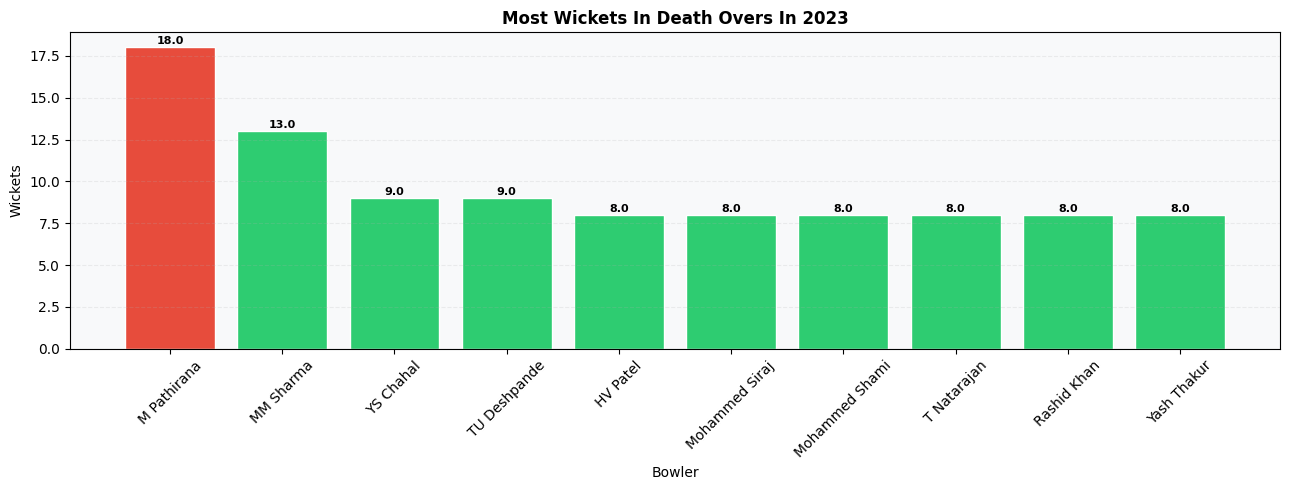


Query: "who dismisses kohli most"
intent=h2h_dismissal | year=None | phase=None | focus=wickets | bowl=None
team=None | venue=None
------------------------------------------------------------

🎯 Top 5 bowlers who dismiss V Kohli most:
        bowler  balls  runs  dismissals  strike_rate  dot_pct
Sandeep Sharma     90   141           7       156.67    28.89
       A Nehra     54    60           6       111.11    55.56
     JJ Bumrah    110   164           5       149.09    36.36
Mohammed Shami     85   119           5       140.00    35.29
      UT Yadav     96   168           5       175.00    29.17


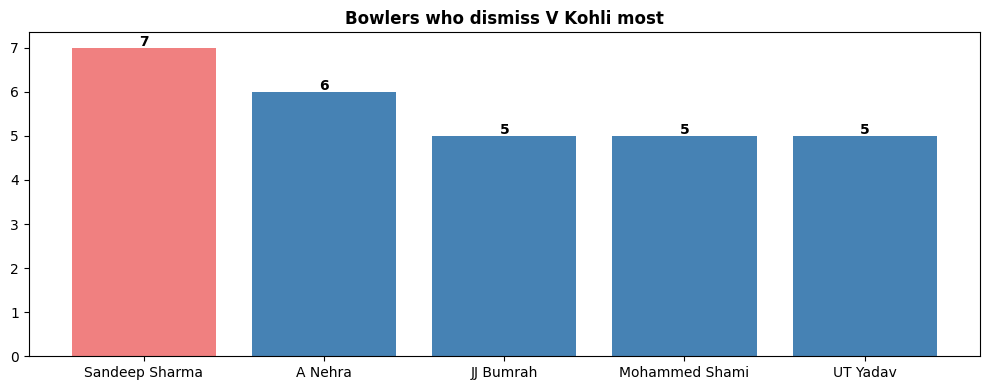


Query: "compare kohli and warner"
intent=compare | year=None | phase=None | focus=None | bowl=None
team=None | venue=None
------------------------------------------------------------

DA Warner vs V Kohli — Career Comparison:
     Metric  DA Warner  V Kohli
 Total Runs    6567.00  8899.00
Strike Rate     140.32   133.84
Batting Avg      40.04    37.87
 Boundary %      19.21    16.53
 Dot Ball %      40.02    35.79
      Sixes     236.00   300.00


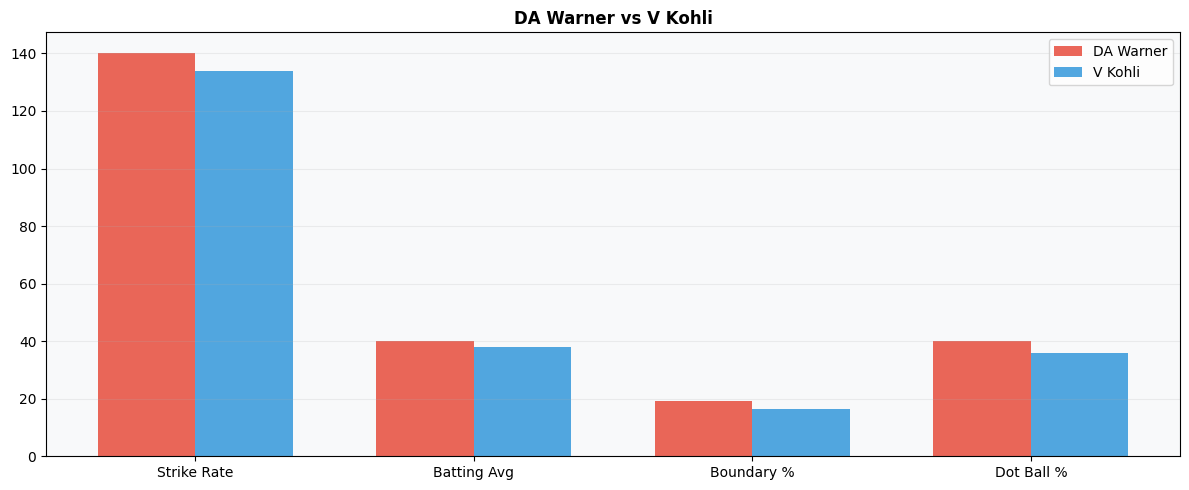

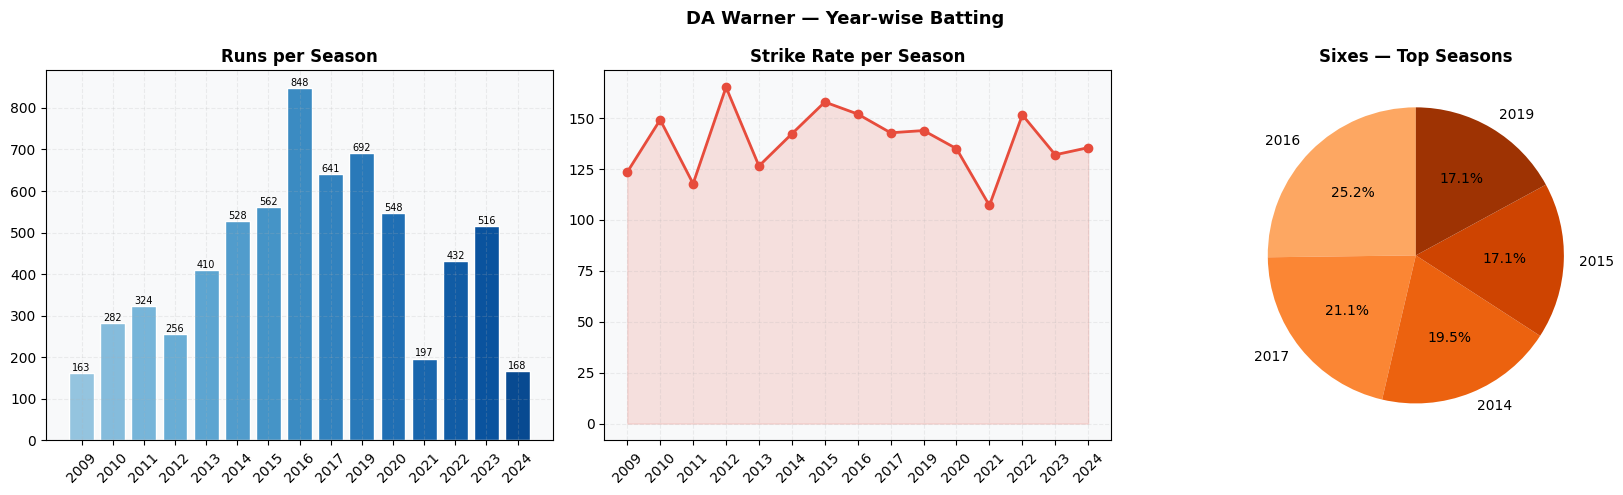

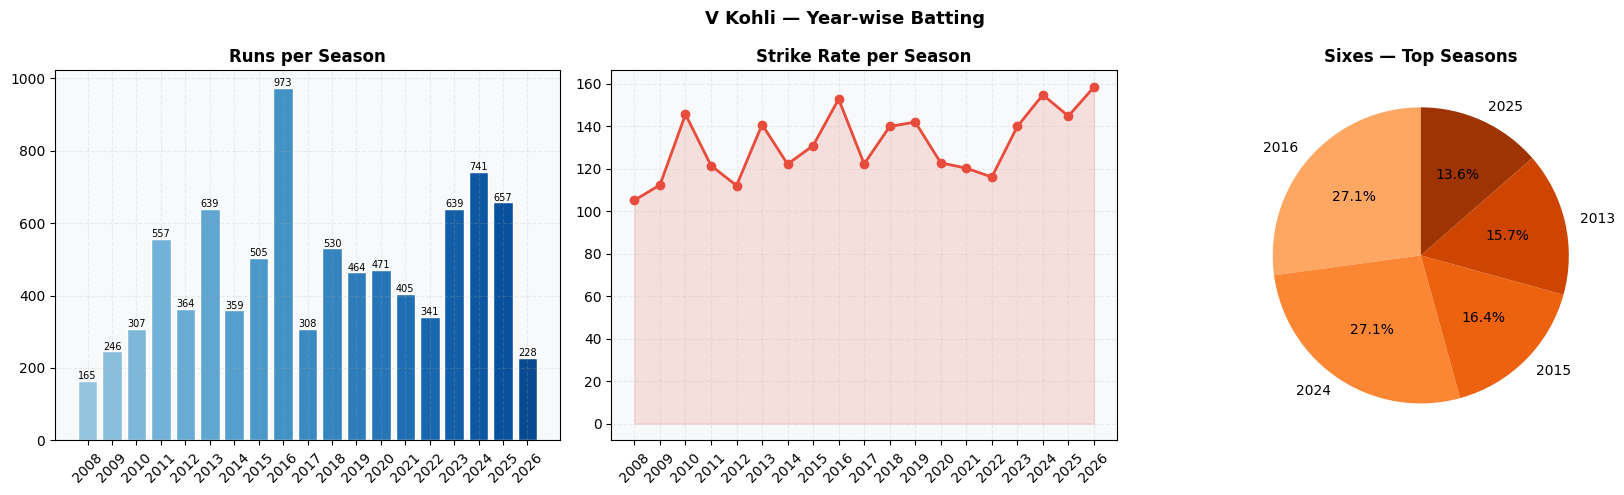


Query: "best chasing team"
intent=team_analytics | year=None | phase=None | focus=None | bowl=None
team=None | venue=None
------------------------------------------------------------

Best Chasing Teams:
                       team  chases  wins  win_pct
              Gujarat Lions      16    12     75.0
    Rising Pune Supergiants      15    10     66.7
             Gujarat Titans      35    23     65.7
        Chennai Super Kings     116    71     61.2
      Kolkata Knight Riders     140    80     57.1
             Mumbai Indians     137    76     55.5
           Rajasthan Royals     130    71     54.6
Royal Challengers Bengaluru     134    72     53.7
               Punjab Kings     129    68     52.7
             Delhi Capitals     151    73     48.3
        Sunrisers Hyderabad     125    57     45.6
       Lucknow Super Giants      27    12     44.4
              Pune Warriors      25     6     24.0


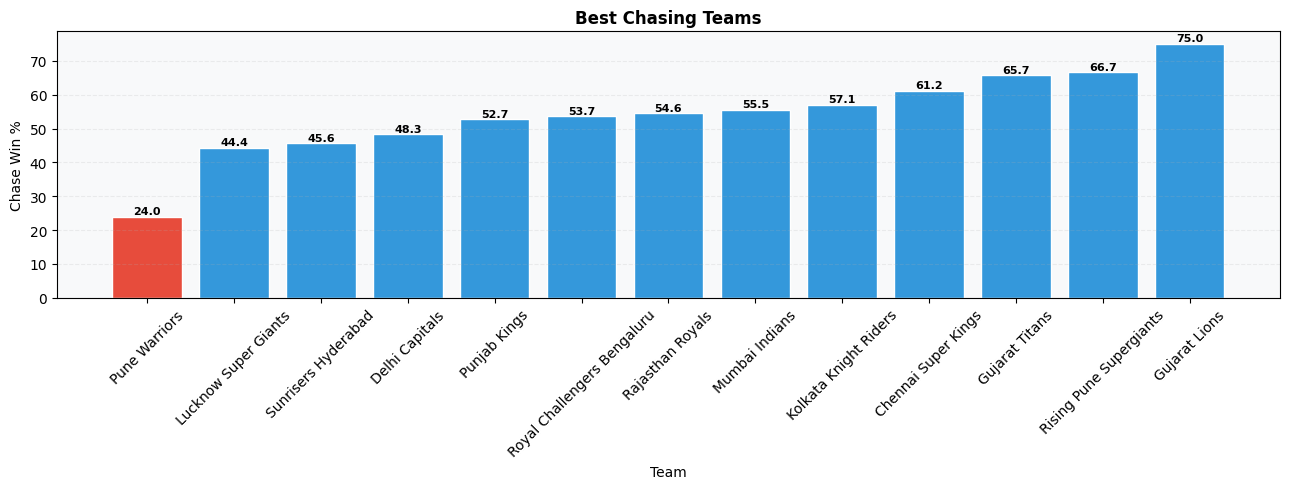


Query: "most runs at wankhede"
intent=recommend_batter | year=None | phase=None | focus=runs | bowl=None
team=None | venue=Wankhede Stadium
------------------------------------------------------------
Filters: Venue=Wankhede Stadium

Top Batters:
        batter  matches  runs  strike_rate    avg  sixes  boundary_pct  score
     RG Sharma       87  2548       139.85  33.53    117         19.26  63.84
      SA Yadav       42  1443       165.67  41.23     61         26.18  47.28
 ST Jayasuriya        4   211       229.35 105.50     17         41.30  43.43
    SO Hetmyer        6   168       158.49 168.00     13         20.75  40.78
    KA Pollard       55  1228       156.83  27.91     85         20.82  39.41
P Simran Singh        2   106       189.29 106.00      4         28.57  34.78
        JJ Roy        2   105       175.00 105.00      7         23.33  32.24
      KL Rahul       13   645       148.62  64.50     31         19.59  32.23
     JM Sharma        5   132       220.00  44.00 

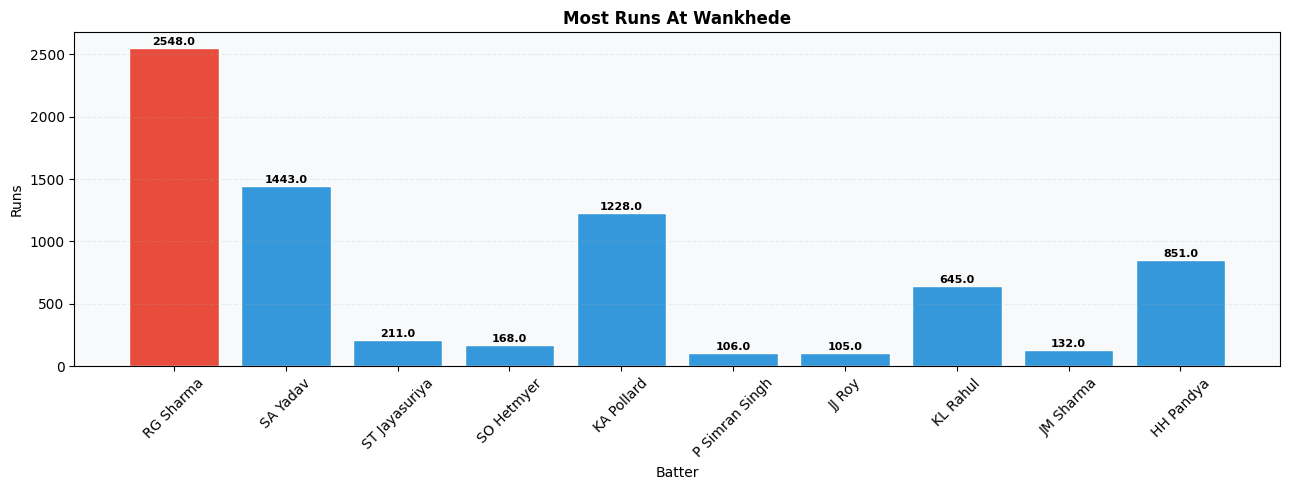


Query: "IPL 2016 stats"
intent=year_stats | year=2016 | phase=None | focus=None | bowl=None
team=None | venue=None
------------------------------------------------------------

IPL 2016 — Season Dashboard

Top Run Scorers 2016:
        batter  matches  runs  strike_rate  avg  sixes
       V Kohli       16   973        152.7 81.1     38
     DA Warner       17   848        152.0 53.0     31
AB de Villiers       16   687        169.6 52.8     37
     G Gambhir       15   501        121.9 41.8      6
      S Dhawan       17   501        117.3 38.5      8
     RG Sharma       14   489        133.6 40.8     17
     AM Rahane       14   480        127.0 36.9      9
       M Vijay       14   453        124.5 37.8     10
     Q de Kock       13   445        136.5 34.2     13
      SK Raina       15   399        127.9 26.6     10

Top Wicket Takers 2016:
           bowler  matches  wickets  economy
          B Kumar       17       23     7.42
        YS Chahal       13       21     8.16
      

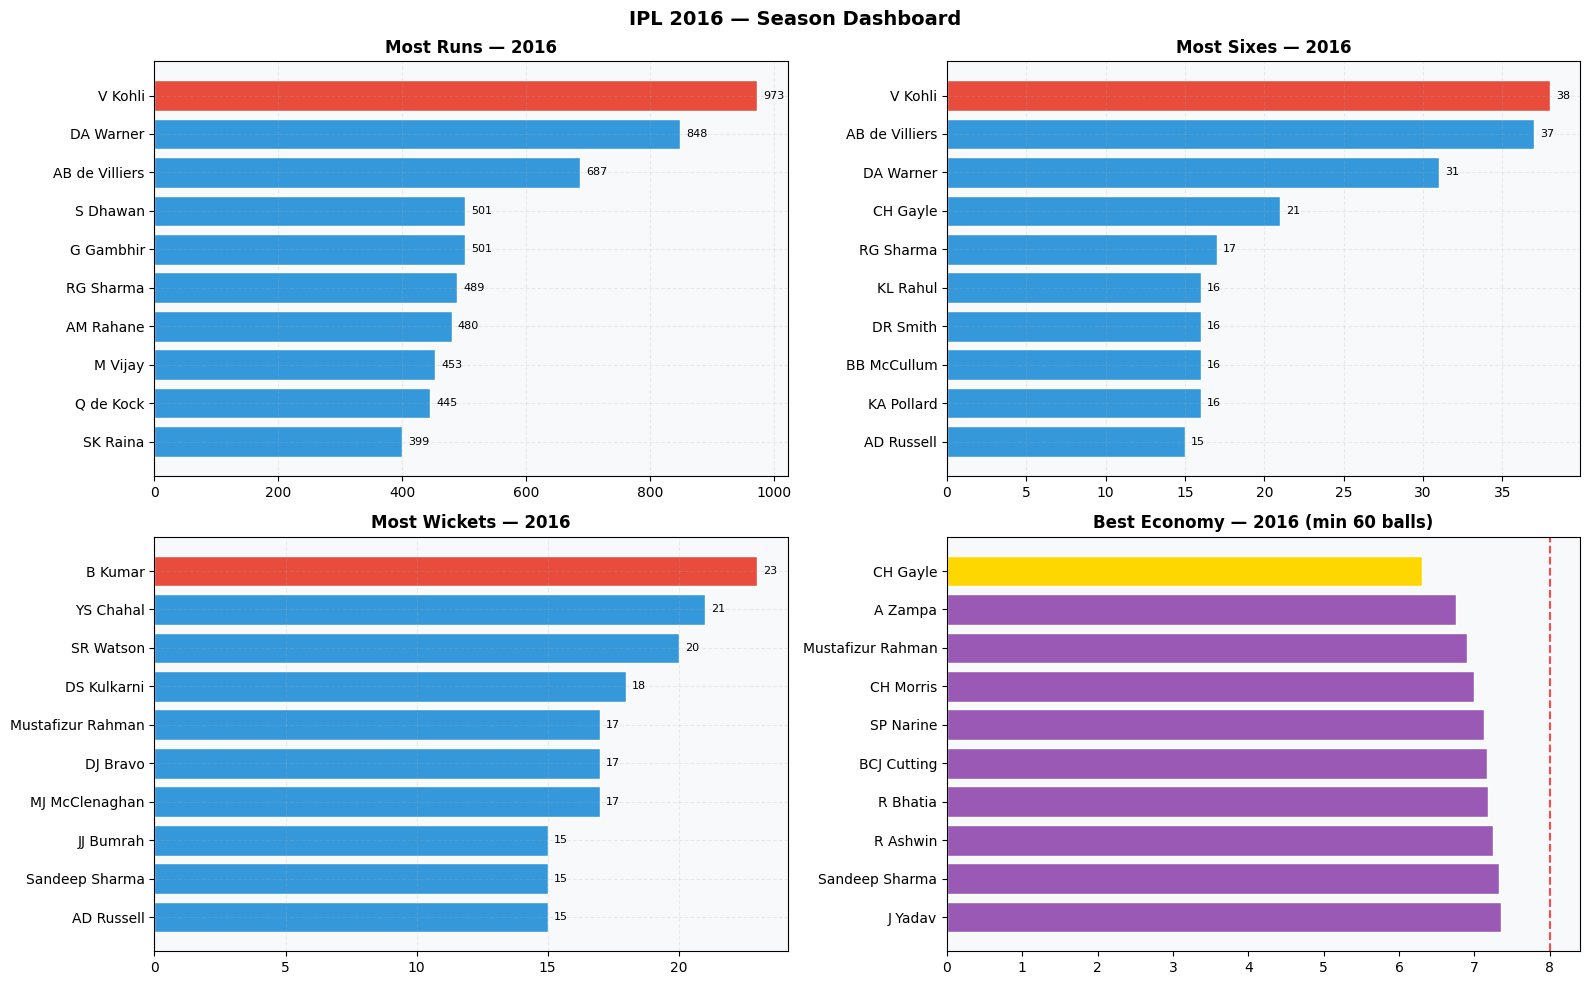


Query: "best spinner at chepauk"
intent=recommend_bowler | year=None | phase=None | focus=None | bowl=spin
team=None | venue=MA Chidambaram Stadium, Chepauk
------------------------------------------------------------
Filters: Venue=MA Chidambaram Stadium | Bowl=spin

Top Bowlers:
           bowler  matches  wickets  economy  dot_pct  wkt_rate  score
          PP Ojha        5       10     5.45    39.17     0.500  87.01
Mustafizur Rahman        6       11     7.75    49.25     0.493  77.13
         A Mishra        7       11     6.68    40.67     0.440  76.12
    Shahbaz Ahmed        5        7     7.92    38.67     0.560  73.55
  Abhishek Sharma        4        4     6.70    36.67     0.400  71.25
        SP Narine        8       10     5.97    35.94     0.312  70.60
       Avesh Khan        5        9     8.47    35.56     0.600  70.31
         R Ashwin       45       49     6.44    40.91     0.286  68.89
        IC Pandey        5        6     7.93    45.56     0.400  68.28
     Ra

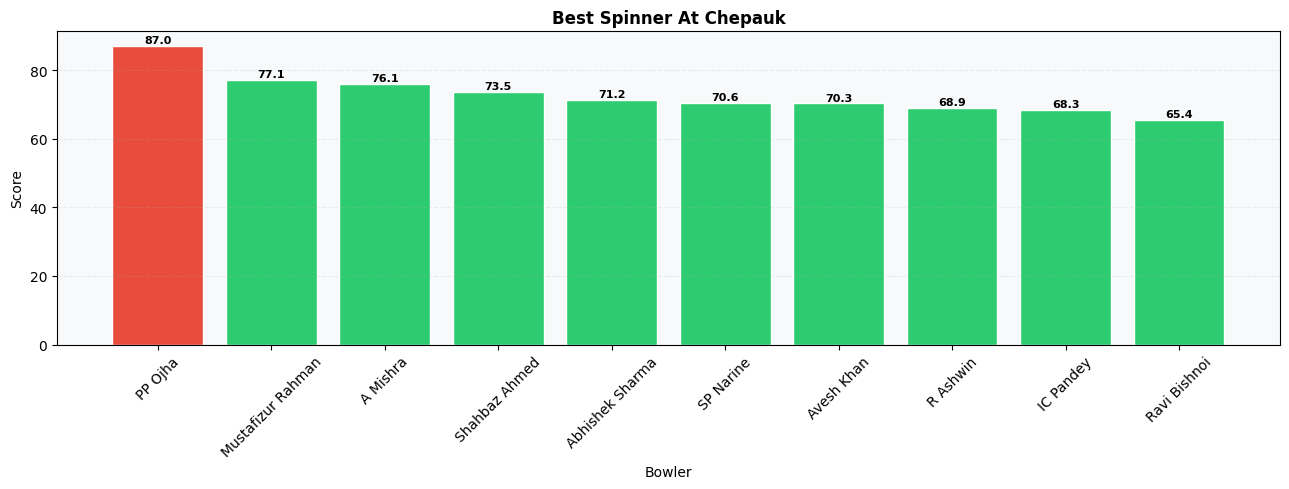

In [73]:
# ── CELL 24 ─ Demo Queries ───────────────────────────────────────────────────

print("\n" + "="*60)
print("DEMO NLP QUERIES")
print("="*60)


run_query("best batter for csk in powerplay in 2019")
run_query("most wickets in death overs in 2023")
run_query("who dismisses kohli most")
run_query("compare kohli and warner")
run_query("best chasing team")
run_query("most runs at wankhede")
run_query("IPL 2016 stats")
run_query("best spinner at chepauk")




Query: "best batman in 2020 season"
intent=year_stats | year=2020 | phase=None | focus=None | bowl=None
team=None | venue=None
------------------------------------------------------------

IPL 2020 — Season Dashboard

Top Run Scorers 2020:
        batter  matches  runs  strike_rate  avg  sixes
      KL Rahul       14   676        129.8 45.1     23
      S Dhawan       17   618        145.4 44.1     13
     DA Warner       16   548        135.0 39.1     14
       SS Iyer       17   519        123.9 32.4     16
  Ishan Kishan       13   516        146.2 57.3     30
     Q de Kock       16   506        140.2 33.7     22
      SA Yadav       15   480        145.5 53.3     11
    D Padikkal       15   473        125.1 33.8      8
       V Kohli       15   471        122.7 42.8     11
AB de Villiers       14   460        160.3 46.0     23

Top Wicket Takers 2020:
        bowler  matches  wickets  economy
      K Rabada       17       32     8.31
     JJ Bumrah       15       29     6.77
   

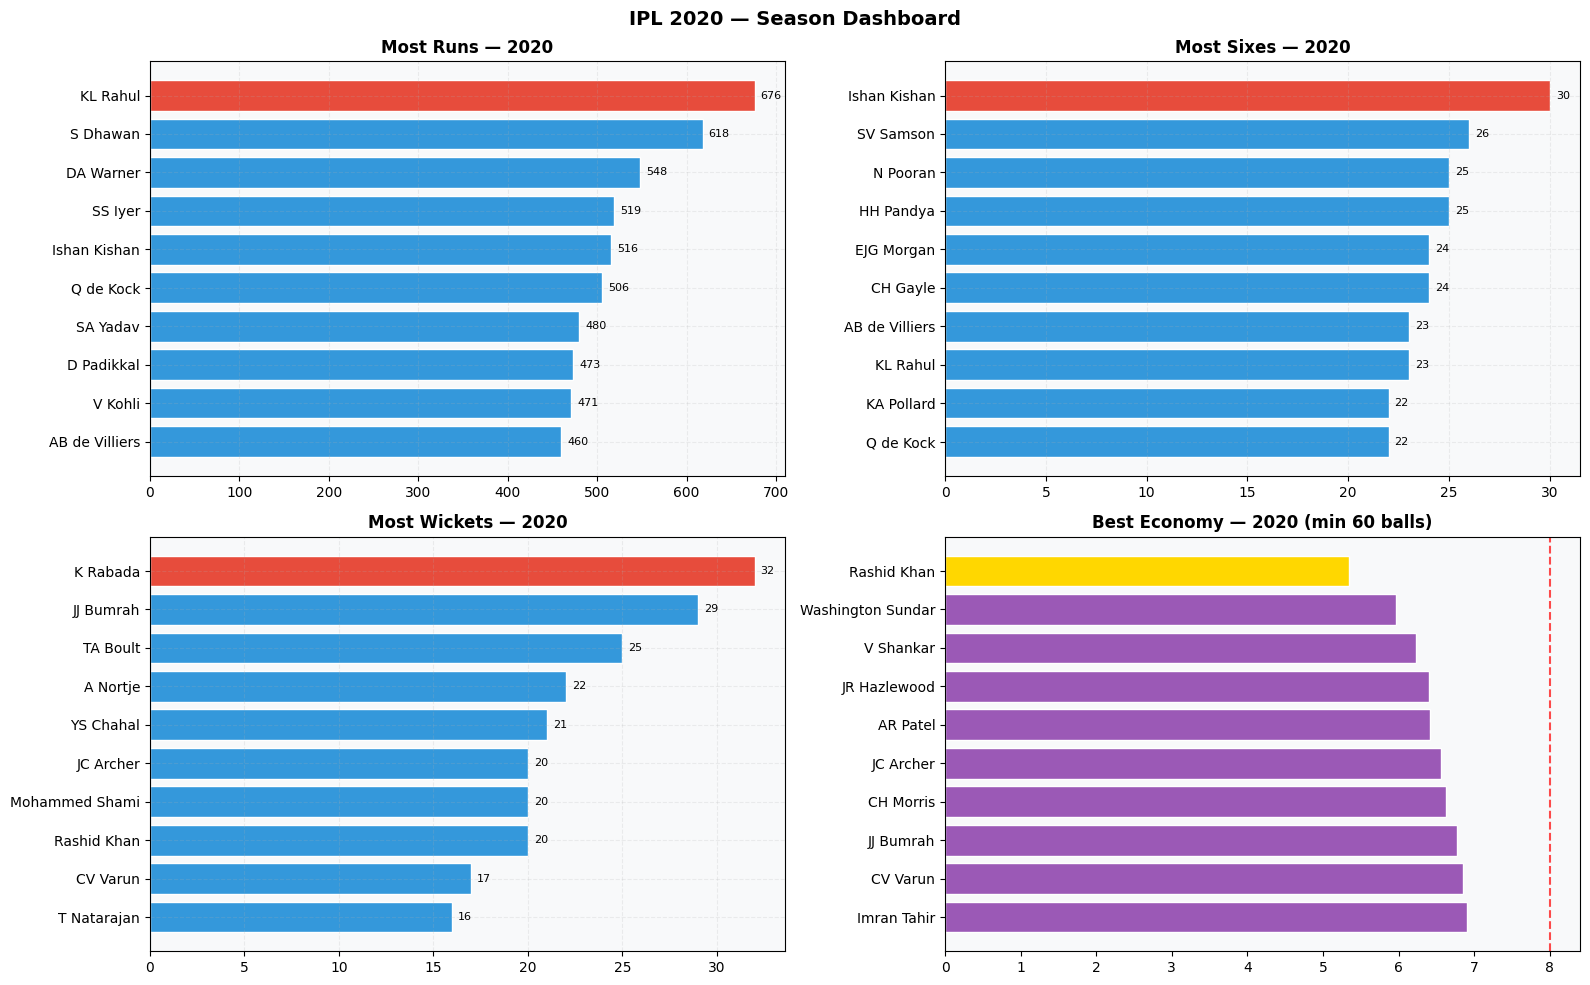

In [64]:
run_query("best batman in 2020 season")